# **AllLife Bank: Personal Loan Prediction**

## **Context**  
AllLife Bank is a US bank that has a growing customer base. The majority of these customers are **liability customer** (depositors) with varying sizes of deposits. The number of customers who are also borrowers **(asset customers)** is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy **conversion rate of over 9% success**. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a **Data Scientist at AllLife Bank** have to build a model that will help the marketing department to identify the **potential customers** who have a higher probability of purchasing the loan.

---

## **Objective**  
To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and to identify which segment of customers to target more. 

---

## **Data Dictionary**  

| Column Name       | Description |
|------------------|-------------|
| **ID**            | Unique Customer ID |
| **Age**           | Customer's age (in completed years) |
| **Experience**    | Number of years of professional experience |
| **Income**        | Annual income of the customer (in thousand dollars) |
| **ZIP Code**      | Home address ZIP code |
| **Family**        | Family size of the customer |
| **CCAvg**         | Average monthly credit card spending (in thousand dollars) |
| **Education**     | Education Level: <br> 1 = Undergrad <br> 2 = Graduate <br> 3 = Advanced/Professional |
| **Mortgage**      | Value of house mortgage (if any) (in thousand dollars) |
| **Personal_Loan** | **Target variable** – Did the customer accept the personal loan offer? (Yes/No) |
| **Securities_Account** | Does the customer have a **securities account** with the bank? (Yes/No) |
| **CD_Account**    | Does the customer have a **certificate of deposit (CD) account**? (Yes/No) |
| **Online**        | Does the customer use **Internet banking**? (Yes/No) |
| **CreditCard**    | Does the customer use a **credit card issued by another bank** (excluding AllLife Bank)? (Yes/No) |

In [1]:
# Data manipulation libraries
import pandas as pd          # For data manipulation and analysis
import numpy as np          # For numerical operations
from pyzipcode import ZipCodeDatabase    # For ZIP code related operations

# Data visualization libraries
import matplotlib.pyplot as plt          # For creating static visualizations
# To display plots in Jupyter notebook
%matplotlib inline                       
import seaborn as sns                    # For enhanced statistical visualizations

# Machine Learning model and utilities from scikit-learn
from sklearn.model_selection import train_test_split    # For splitting data into train and test sets
from sklearn.tree import DecisionTreeClassifier         # The decision tree classifier model
from sklearn import tree                                # For decision tree operations

# Model evaluation metrics and visualization tools
from sklearn.metrics import (
    f1_score,                    # For F1 score calculation
    accuracy_score,              # For accuracy calculation
    recall_score,                # For recall calculation
    precision_score,             # For precision calculation
    ConfusionMatrixDisplay,      # For visualizing confusion matrix
    make_scorer,                 # For creating custom scoring metrics
    confusion_matrix             # For creating confusion matrix
)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")    # To ignore unnecessary warnings during execution


In [2]:
# Reading the dataset
df = pd.read_csv('Loan_Modelling.csv')
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


- Dataset consists of 5000 rows and 14 columns.
- All the features are either integer or float datatype.

In [4]:
# checking for missing values
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

- Dataset contains no null values

In [5]:
# Dropping the ID column
df.drop(columns = ['ID'], inplace = True)

In [6]:
# Checking the statistical summary of the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities_Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


#### **Statistical Description:**
1. **Age & Experience**: Customers are typically **45 years old**, and the maximum years of professional experience of the customers is 43.
2. **Income**: Income varies widely, averaging **$73.77K**, with some earning up to **$224K**.  
3. **ZIP Code**: All customers belong to a similar region, ranging from **90005 to 96651**.  
4. **Family Size**: Most customers have **small families**, with an average of **2 to 3 members**.  
5. **Credit Card Spending (CCAvg)**: Customers spend an average of **$1.94K per month**, with some spending as high as **$10K**.  
6. **Education**: Most customers have at least an **undergraduate or graduate degree**, with a few holding advanced degrees.  
7. **Mortgage**: While the average mortgage is **$56.5K**, a few customers have mortgages as high as **$635K**.  
8. **Personal Loan**: Only **9.6% of customers** have taken a personal loan, indicating low adoption.  
9. **Securities Account**: A niche product, with only **10.4% of customers** maintaining one.  
10. **CD Account**: Even less common, as only **6% of customers** hold a certificate of deposit.  
11. **Online Banking**: Digital adoption is strong, with **59.7% of customers** using online banking.  
12. **Credit Card**: Nearly **one-third (29.4%)** of customers own a credit card issued by the bank.  

-----
## **Univariate Analysis**
-----

In [7]:
def univariate_analysis(data,col,cat=False):
    sns.set_palette(['darkturquoise'])
    colors = ['lightcoral','lightsalmon','palegoldenrod','lightgreen']

    if cat:
        fig, ax = plt.subplots(1, 2, figsize = (10,3));

        sns.countplot(data = data, x = col, ax = ax[0])
        ax[0].set_title(f'{col} Distribution (Countplot)');

        # Plotting Pie Chart
        value_counts = data[col].value_counts()
        sizes = value_counts.values 
        labels = value_counts.index 

        chart_colors = colors[:len(labels)]
        
        ax[1].pie(
            sizes,
            labels=labels,
            autopct='%1.1f%%', 
            startangle=90,       
            colors=chart_colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        );
        ax[1].set_title(f'{col} Distribution (Pie Chart)');
        return
    fig, ax = plt.subplots(1, 2, figsize = (10,3));

    sns.histplot(data = data, x = col, ax = ax[0], kde=True)
    ax[0].set_title(f'{col} Distribution (Histogram)');
    ax[0].axvline(data[col].mean(), c = 'r', linestyle='--', linewidth=2, label=f'Mean: {data[col].mean():.2f}')
    ax[0].axvline(data[col].median(), c = 'y', linestyle='-', linewidth=2, label=f'Median: {data[col].median():.2f}')
    ax[0].legend(loc='upper right')

    sns.boxplot(data = data, x = col, ax = ax[1])
    ax[1].set_title(f'{col} Distribution (Boxplot)');

### **1. Age**
*Description: Customer's age (in completed years)*

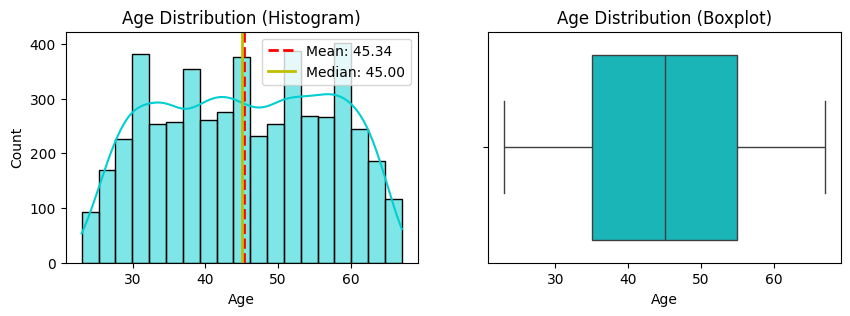

In [8]:
univariate_analysis(df,'Age')

#### **Observations:**
From the univariate analysis of the Age variable, several key insights emerge:

**Central Tendency**
- The mean and median ages are approximately 45-46 years, as indicated by the red (mean) and yellow (median) lines in the histogram.
- The close proximity of mean and median suggests a relatively symmetric distribution.

**Age Range and Spread**
- The age range spans from approximately 25 to 65 years.
- The majority of customers fall between 35-55 years, as shown by the denser bars in the histogram.
- The boxplot indicates no significant outliers in the age distribution.

**Distribution Shape**
- The distribution appears to be roughly bell-shaped with a slight right skew.
- There are multiple peaks, with notable concentrations around ages 35-40 and 45-50.
- The frequency counts show that the most populated age groups have approximately 350-400 customers.

This age distribution suggests that the bank's customer base is predominantly middle-aged, with fewer very young or elderly customers.

### **2. Experience**
*Description: Number of years of professional experience*

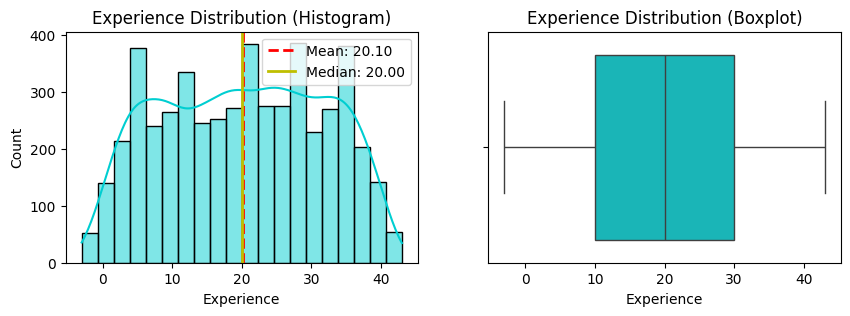

In [9]:
univariate_analysis(df,'Experience')

#### **Observations:**
From the univariate analysis of the Experience variable, several key insights emerge:

**Central Tendency**
- The mean (red line) and median (yellow line) experience levels are approximately 20 years.
- The close alignment of mean and median indicates a fairly symmetric distribution

**Experience Range and Spread**
- The experience range spans from -3 to approximately 43 years. Having negative years of experience (-3 years) in the dataset indicates a data quality issue that needs to be addressed.
- The majority of customers have between 10-35 years of experience

**Distribution Shape**
- The distribution appears roughly bell-shaped with multiple small peaks
- The highest frequency counts show approximately 350-400 customers in the most common experience brackets
- The distribution tapers off gradually at both ends, with fewer customers having very low (<5 years) or very high (>40 years) experience

This experience distribution suggests a workforce predominantly composed of mid-career to senior professionals, which aligns with the age distribution previously observed.

### **3. Income**
*Description: Annual income of the customer (in thousand dollars)*

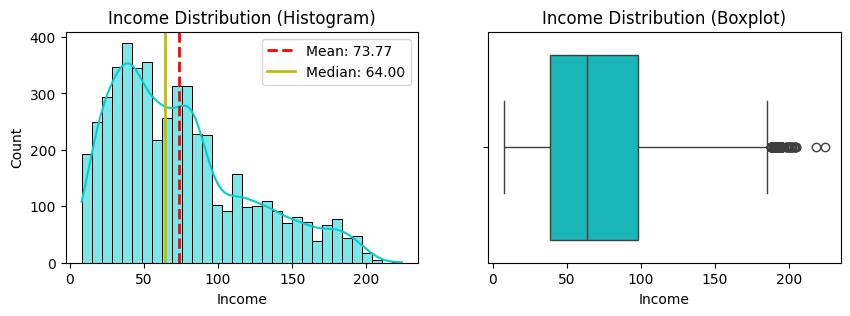

In [10]:
univariate_analysis(df,'Income')

#### **Observations:**

From the univariate analysis of Income (in thousand dollars), several key insights emerge:

**Central Tendency**
- The mean income (red dashed line) is higher than the median (yellow line), indicating a right-skewed distribution.

**Income Range and Spread**
- Income ranges from approximately 0 to 200+ thousand dollars.
- The majority of customers earn between 25-100 thousand dollars.
- The boxplot reveals numerous outliers on the higher end (above 185 thousand dollars).
- The interquartile range (box in the boxplot) shows the middle 50% of incomes fall between approximately 45-100 thousand dollars.

**Distribution Shape**
- The distribution is notably right-skewed (positively skewed).
- The highest concentration of customers (peak) occurs around 45-60 thousand dollars.
- The frequency gradually decreases as income increases, with fewer customers in higher income brackets.

This income distribution suggests that while most customers are middle-income earners, the bank has a significant number of high-income customers creating the right skew in the distribution.

### **4. ZIPCode**
*Description: Home address ZIP code*

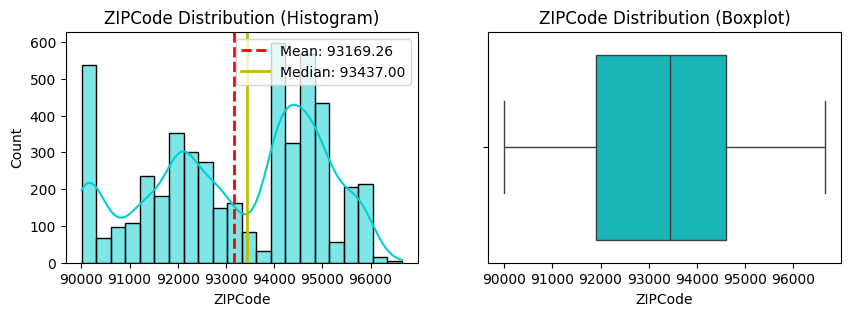

In [11]:
univariate_analysis(df,'ZIPCode')

#### **Observations:**
From the univariate analysis of ZIP codes, several key patterns emerge:

**ZIP Code Range**
- The ZIP codes span from approximately 90000 to 96000
- Most customers are concentrated in two main clusters: around 90000-91000 and 94000-95000

**Distribution Pattern**
- The histogram shows two major concentrations of customers:
  * A large cluster around ZIP code 90000 with approximately 500 customers
  * Another significant cluster around ZIP code 94000-95000 with about 600 customers
- There's a relatively lower frequency of customers in the middle range (92000-93000)
- The distribution tapers off, with very few customers in ZIP codes above 96000

The distribution suggests that the bank's customers are primarily concentrated in two distinct geographical areas, which could be useful for targeted marketing or branch location planning.

### **5. Family**
*Description: Family size of the customer*

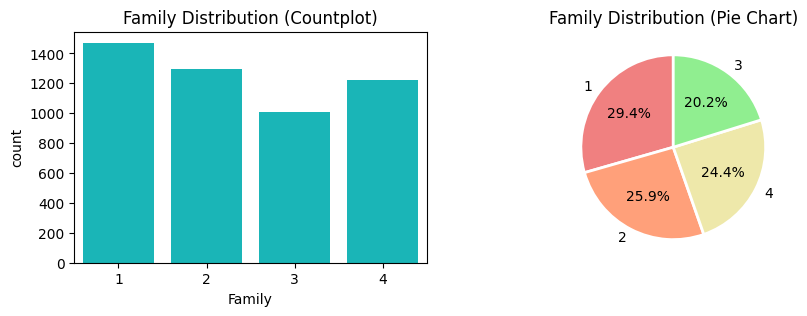

In [12]:
univariate_analysis(df,'Family',True)

#### **Observations:**
From the univariate analysis of family size distribution, several key insights emerge:

**Family Size Breakdown**
- 1 member (Single): 29.4% of customers (approximately 1,400 customers)
- 2 members: 25.9% of customers (approximately 1,300 customers)
- 3 members: 20.2% of customers (approximately 1,000 customers)
- 4 members: 24.4% of customers (approximately 1,200 customers)

**Distribution Pattern**
- The count plot shows a decreasing trend from single-member families to 3-member families, with a slight uptick for 4-member families
- Single-member households form the largest segment, suggesting a significant proportion of individual customers
- The distribution is relatively balanced, with each family size category representing between 20-30% of the total customer base
- There are no families larger than 4 members in the dataset

This family size distribution indicates that the bank serves a diverse range of household sizes, with a slight skew toward smaller family units.

### **6. CCAvg (Credit Card Average Spending per Month)**  
- The **average amount of money** a customer spends using their **credit card** each month.  
- **Higher spending** may indicate a customer is **comfortable with debt** and might be **open to taking a loan**. 

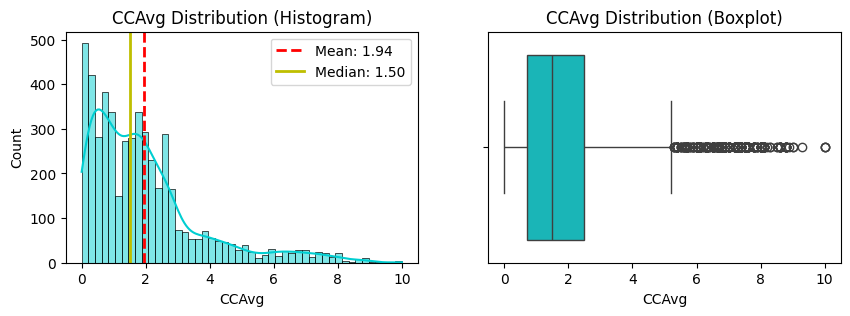

In [13]:
univariate_analysis(df,'CCAvg')

#### **Observations:**
From the univariate analysis of Credit Card Average monthly spending (CCAvg) in thousand dollars, several key insights emerge:

**Central Tendency**
- The mean (red dashed line) is higher than the median (yellow line), indicating a right-skewed distribution

**Spending Range and Spread**
- CCAvg ranges from 0 to approximately 10 thousand dollars per month
- The boxplot reveals numerous outliers above 5 thousand dollars
- The interquartile range (box in boxplot) shows the middle 50% of spending falls between approximately 1-3 thousand dollars

**Distribution Shape**
- The distribution is heavily right-skewed (positively skewed)
- The highest concentration of customers (peak) occurs in the 0-2 thousand dollar range
- There's a long right tail extending to 10 thousand dollars
- The frequency dramatically decreases as spending increases, with very few customers spending above 6 thousand dollars monthly

This spending distribution suggests that while most customers are moderate credit card users, there exists a small segment of high-spending customers who significantly influence the mean spending amount.

### **7. Education**

Education Level:
1 = Undergrad
2 = Graduate
3 = Advanced/Professional


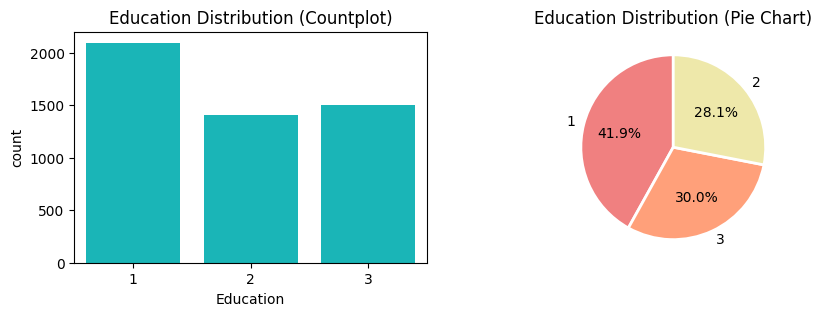

In [14]:
univariate_analysis(df,'Education',True)
print('Education Level:\n1 = Undergrad\n2 = Graduate\n3 = Advanced/Professional')

#### **Observations:**
From the univariate analysis of Education levels, several key insights emerge:

**Education Level Breakdown**
- Undergrad (1): 41.9% of customers (approximately 2,100 customers)
- Graduate (2): 28.1% of customers (approximately 1,400 customers)
- Advanced/Professional (3): 30.0% of customers (approximately 1,500 customers)

**Distribution Pattern**
- Undergraduate degree holders form the largest segment, representing nearly half of the customer base
- Advanced/Professional degree holders slightly outnumber Graduate degree holders
- All three education levels maintain significant representation, with no single category being notably underrepresented

This education distribution indicates that the bank's customer base is well-educated overall, with a particularly strong representation of undergraduate degree holders. The relatively high proportion of Advanced/Professional degree holders (30%) suggests a significant segment of highly educated customers.

### **8. Mortgage**  
- A **mortgage** is a loan taken to buy a **house** or **property**.  
- The property itself is used as **collateral** (security).  
- If the borrower **fails to repay**, the bank can **seize the property** to recover its money.  

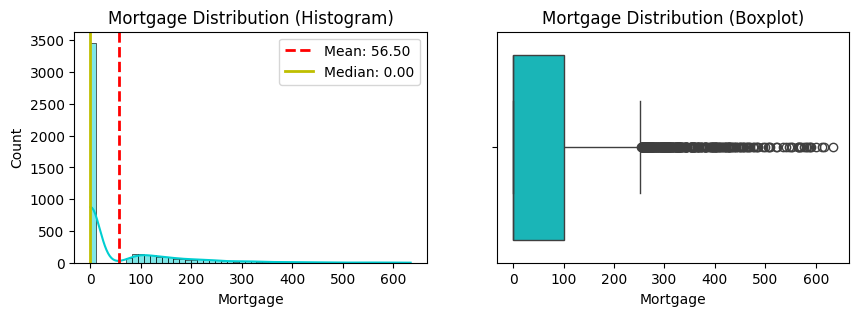

In [15]:
univariate_analysis(df,'Mortgage')

#### **Observations:**
From the univariate analysis of Mortgage values (in thousand dollars), several key insights emerge:

**Central Tendency**
- The mean (red dashed line) is higher than the median (yellow line), indicating a strong right-skewed distribution
- A large number of customers (approximately 3,500) have zero or very low mortgage values
- The median mortgage value appears to be close to zero, suggesting most customers don't have mortgages

**Mortgage Range and Spread**
- Mortgage values range from 0 to approximately 650 thousand dollars
- The boxplot shows numerous outliers extending beyond 250 thousand dollars
- The interquartile range (box in boxplot) is relatively small compared to the full range, indicating high concentration at lower values

**Distribution Shape**
- The distribution is extremely right-skewed (positively skewed)
- There's a dominant peak at zero/near-zero values
- A long right tail extends to higher mortgage values
- After the initial peak, there's a rapid decline in frequency, with relatively few customers having mortgages above 250 thousand dollars

This mortgage distribution suggests that while most bank customers have little to no mortgage, there exists a small segment with significant mortgage values, creating the long right tail in the distribution.

### **9. Personal Loan**  
- A **personal loan** is a loan that a customer can take from a bank for **personal expenses** such as **medical bills, education, home renovation**, or any other purpose.  
- It is usually **unsecured**, meaning **no collateral** (like a **house** or **car**) is required.  
- The customer **repays** it in **fixed monthly installments** with **interest**.  

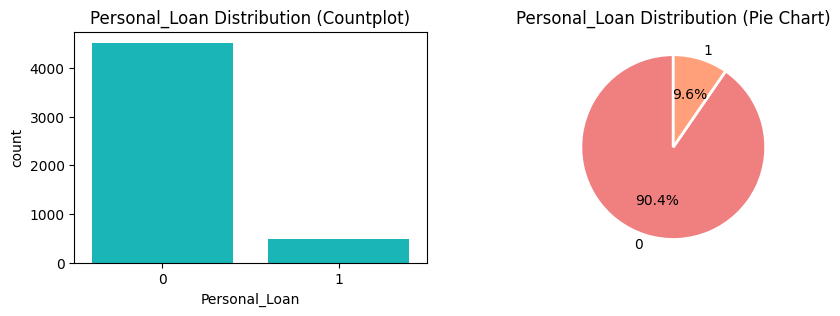

In [16]:
univariate_analysis(df,'Personal_Loan',True)

#### **Observations:**

From the univariate analysis of Personal Loan (target variable), several key insights emerge:

**Class Distribution**
- No (0): 90.4% of customers (approximately 4,500 customers) did not accept the personal loan offer
- Yes (1): 9.6% of customers (approximately 480 customers) accepted the personal loan offer

**Key Observations**
- The dataset shows a significant class imbalance
- The acceptance rate for personal loans is relatively low at under 10%
- The count plot clearly illustrates the large disparity between acceptance and rejection counts

This highly imbalanced distribution suggests that:
- Personal loan acceptance is a relatively rare event in this customer base
- The bank might want to investigate factors influencing the low acceptance rate

### **10. Securities Account**  
- A **securities account** is an **investment account** where customers hold **financial assets** like **stocks, bonds, and mutual funds**.  
- If a customer has a **securities account**, they might be **financially well-off** and may **not need a personal loan**.

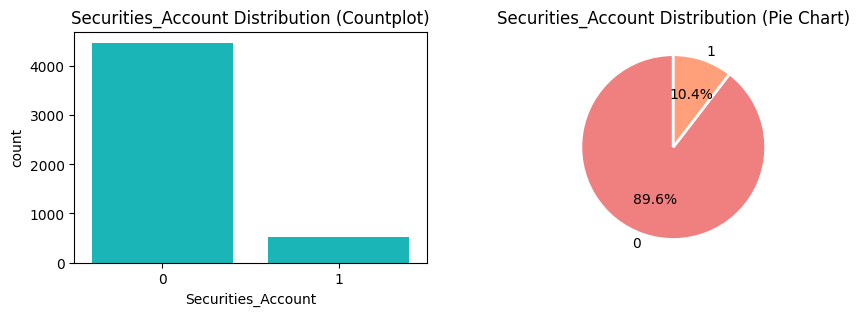

In [17]:
univariate_analysis(df,'Securities_Account',True)

#### **Observations:**
From the univariate analysis of Securities Account distribution, several key insights emerge:

**Account Distribution**
- No (0): 89.6% of customers (approximately 4,480 customers) do not have a securities account
- Yes (1): 10.4% of customers (approximately 520 customers) have a securities account

**Key Observations**
- The dataset shows a significant imbalance in securities account ownership
- Only about 1 in 10 customers maintains a securities account with the bank
- Both the count plot and pie chart clearly illustrate the large disparity between account holders and non-holders

This highly skewed distribution suggests that securities accounts are a specialized product with limited adoption among the bank's customer base, possibly indicating an opportunity for growth in this service offering.

### **11. CD Account (Certificate of Deposit Account)**  
- A **CD (Certificate of Deposit) account** is a type of **savings account** where money is **deposited for a fixed period** (e.g., **1 year, 5 years**) with a **higher interest rate** than regular savings accounts.  
- The money **cannot be withdrawn before maturity** without paying a **penalty**.  

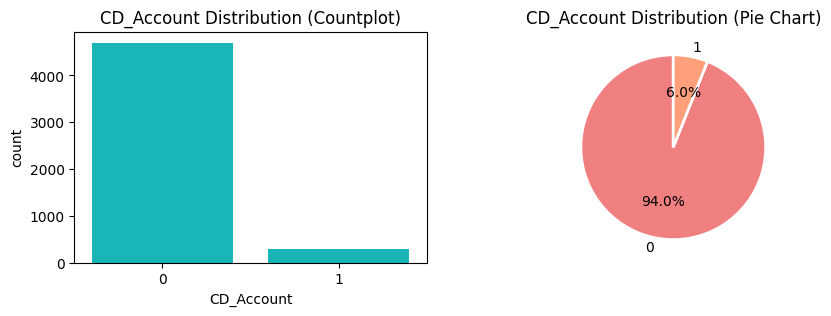

In [18]:
univariate_analysis(df,'CD_Account',True)

#### **Observations:**
From the univariate analysis of CD (Certificate of Deposit) Account distribution, several key insights emerge:

**Account Distribution**
- No (0): 94.0% of customers (approximately 4,700 customers) do not have a CD account
- Yes (1): 6.0% of customers (approximately 300 customers) have a CD account

**Key Observations**
- The dataset shows a severe imbalance in CD account ownership
- Only about 1 in 17 customers holds a CD account with the bank
- The count plot shows a dramatic difference between account holders and non-holders
- CD accounts have the lowest adoption rate compared to securities accounts and personal loans

With only 6% of customers holding CD accounts, this financial product shows the lowest adoption rate among the bank's offerings, pointing to potential gaps in marketing strategy or a niche appeal to investors.

### **12. Online**

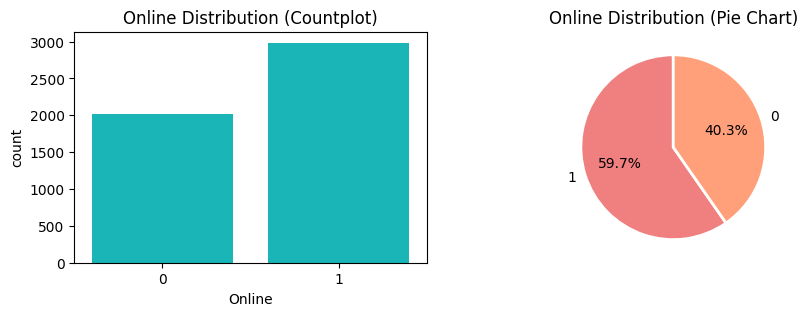

In [19]:
univariate_analysis(df,'Online',True)

#### **Observations:**
From the univariate analysis of Online banking usage, several key insights emerge:

**Online Banking Usage**
- No (0): 40.3% of customers (approximately 2,000 customers) do not use internet banking
- Yes (1): 59.7% of customers (approximately 3,000 customers) use internet banking

**Key Observations**
- The majority of customers have adopted online banking services
- The distribution is relatively balanced, with a moderate skew toward online banking users
- The count plot shows a clear difference of about 1,000 customers between users and non-users
- Nearly 6 out of 10 customers engage with the bank's digital services

This distribution suggests a healthy adoption rate of digital banking services, though there remains a substantial segment of customers who have not yet embraced online banking.

### **13. Credit Card**  
- A **credit card** allows customers to **borrow money** from the bank **up to a certain limit** and **pay it back later**.  
- The dataset specifically asks whether the customer uses a **credit card from another bank** (not **AllLife Bank**).  
- This helps determine their **financial habits** and **potential for taking loans**. 

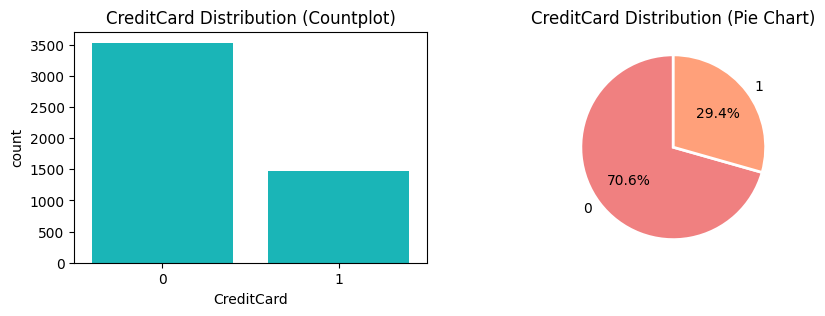

In [20]:
univariate_analysis(df,'CreditCard',True)

#### **Observations:**
From the univariate analysis of Credit Card distribution (credit cards issued by other banks), several key insights emerge:

**Credit Card Ownership**
- No (0): 70.6% of customers (approximately 3,500 customers) do not have credit cards from other banks
- Yes (1): 29.4% of customers (approximately 1,500 customers) have credit cards from other banks

**Key Observations**
- The majority of customers do not hold credit cards from competing banks
- About 3 out of 10 customers maintain credit card relationships with other banks
- The pie chart clearly illustrates the significant disparity between the two segments

This distribution indicates that while most customers don't have external credit card relationships, there's still a substantial minority who use competitors' credit cards, suggesting potential opportunities for the bank to expand its credit card customer base.

----
## **Bivariate Analysis**
----

In [21]:
num_col = ['Age','Experience','Income','CCAvg','Mortgage']
cat_col = ['Family','Education','Personal_Loan','Securities_Account','CD_Account','Online','CreditCard']

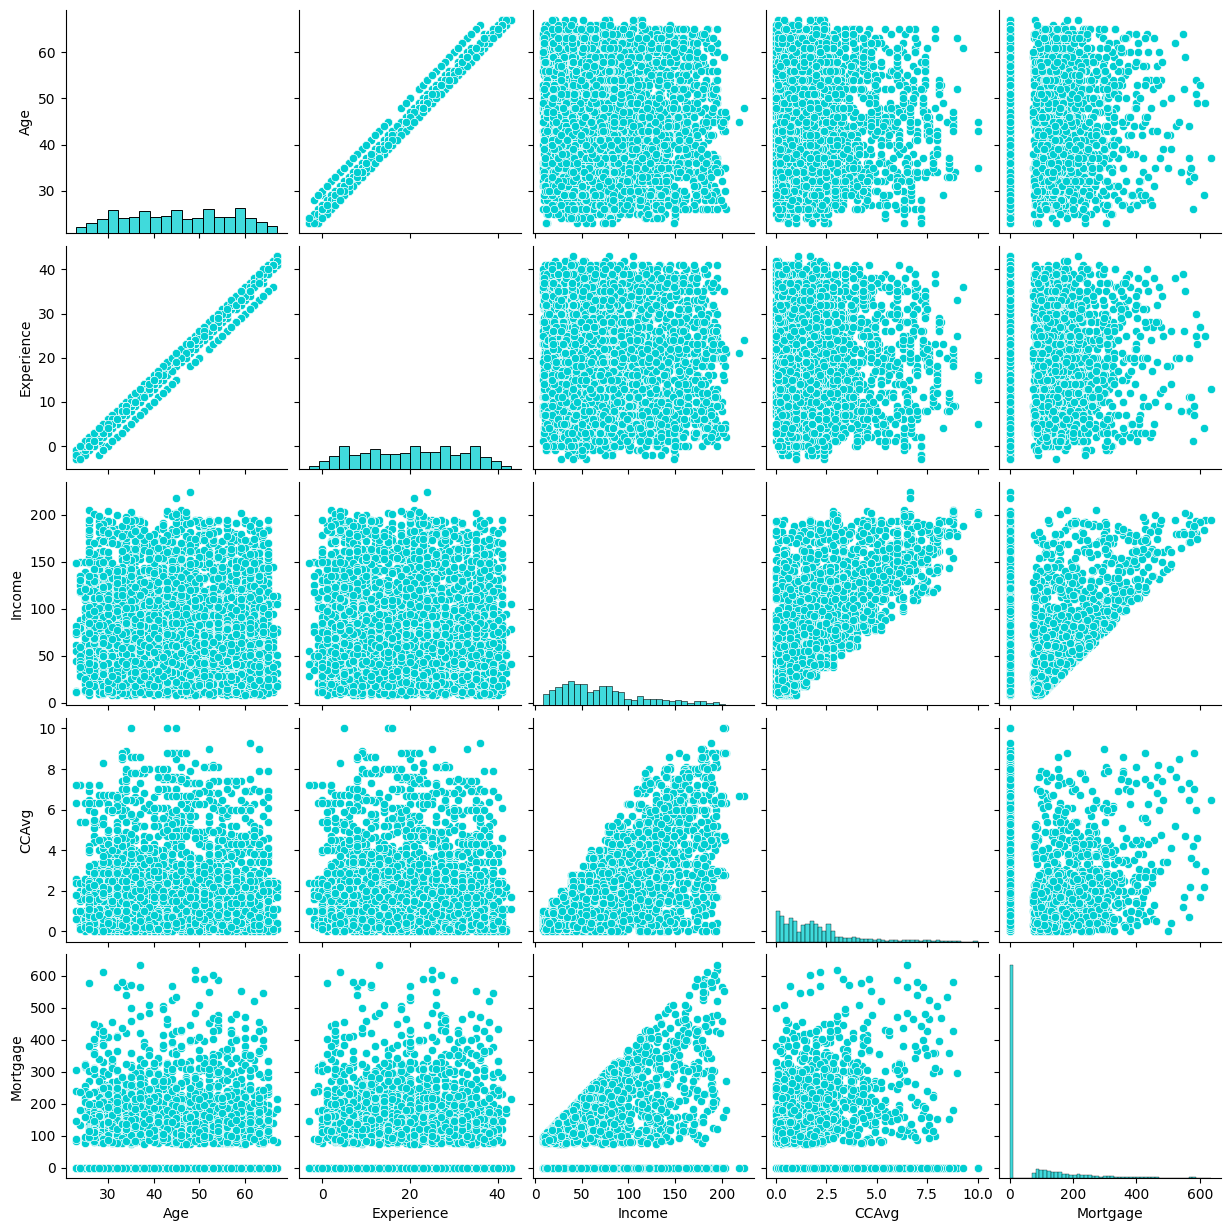

In [22]:
sns.pairplot(df[num_col]);

#### **Observations:**
From the pairplot visualization of numerical variables, here's a comprehensive bivariate analysis:

1) **Age vs Other Variables**
- **Age vs Experience**: Shows a strong positive linear correlation, indicating experience increases proportionally with age
- **Age vs Income**: Weak positive relationship with significant scatter, suggesting age isn't a strong determinant of income
- **Age vs CCAvg**: Very weak correlation, indicating credit card spending isn't strongly influenced by age
- **Age vs Mortgage**: No clear pattern, suggesting mortgage amounts are independent of age

2) **Experience vs Other Variables**
- **Experience vs Income**: Similar to age, shows a weak positive relationship
- **Experience vs CCAvg**: No clear pattern, indicating experience doesn't influence CCAvg
- **Experience vs Mortgage**: No clear pattern, indicating experience doesn't influence mortgage amounts

3) **Income vs Other Variables**
- **Income vs CCAvg**: Shows a moderate positive correlation - higher income individuals tend to have higher credit card spending
- **Income vs Mortgage**: Displays a positive relationship, suggesting higher income customers tend to have larger mortgages

4) **CCAvg vs Other Variables**
- **CCAvg vs Mortgage**: Shows a positive correlation - customers with higher credit card spending tend to have larger mortgages

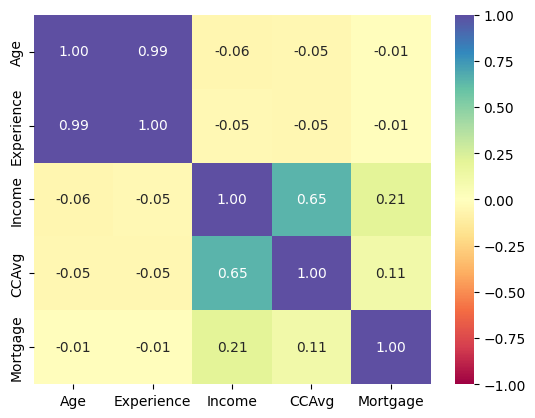

In [23]:
sns.heatmap(df[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral");

#### **Observations: Correlation Analysis between Numerical variables**

**1. Strong Correlation**  
- **Age vs. Experience (0.99):**  
  - There is a **near-perfect positive correlation**.  
  - This is expected since **professional experience increases with age**.  

**2. Moderate Correlation**  
- **Income vs. CCAvg (0.65):**  
  - There is a **moderate positive correlation**.  
  - Higher income customers tend to **spend more on credit cards**.  

**3. Weak Correlations**  
- **Income vs. Mortgage (0.21):**  
  - A **weak positive correlation** exists.  
  - This suggests customers with **higher income** might take slightly **larger mortgages**.  
- **CCAvg vs. Mortgage (0.11):**  
  - There is **minimal correlation**, implying no **strong relationship** between credit card spending and mortgage.  

**4. Negligible Correlations**  
- Variables like **Age, Experience** with **Income, CCAvg, and Mortgage** show **weak or no significant correlation**.  

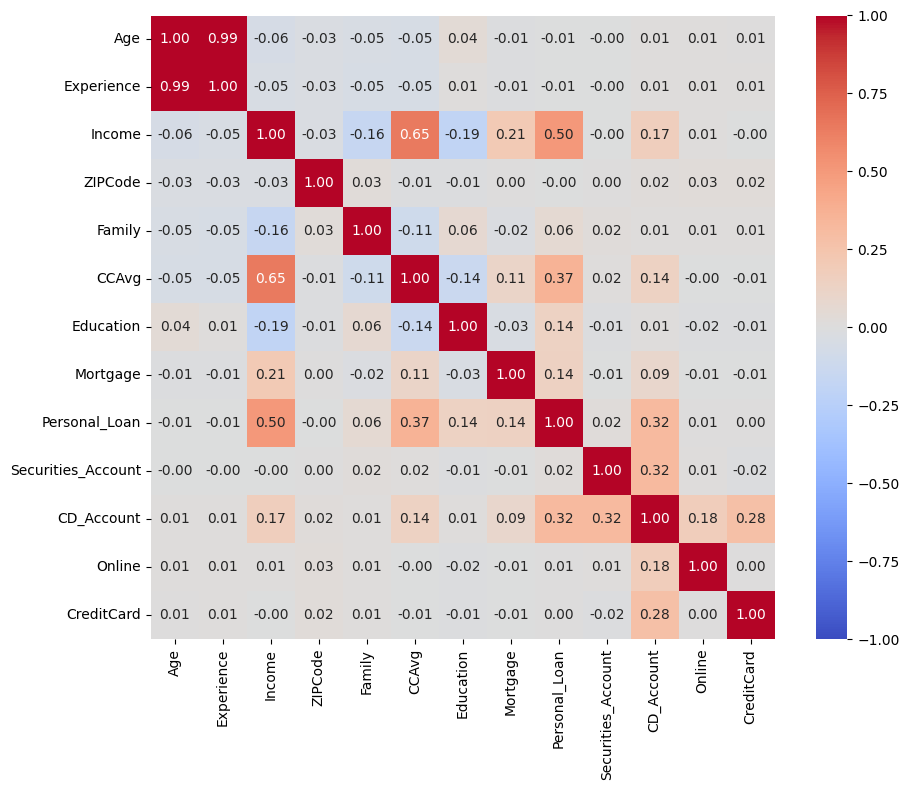

In [24]:
# Creating a larger figure size
plt.figure(figsize=(10, 8))

# Creating heatmap with customized parameters
sns.heatmap(df.corr(), 
            annot=True,             
            cmap='coolwarm',         
            vmin=-1, vmax=1,         
            center=0,                
            fmt='.2f',             
            square=True,            
            annot_kws={'size': 10}) 

plt.tight_layout()

#### **Observations: Correlation Analysis between Numerical and Categorical variables**

##### Strong Correlations (|r| > 0.3)
- **Income vs Personal_Loan**: Strong positive correlation (0.50), indicating higher income individuals are more likely to accept personal loans
- **CCAvg vs Personal_Loan**: Moderate positive correlation (0.37), indicating higher credit card spenders are more likely to accept personal loans

##### Moderate to Weak Correlations (0.1 < |r| < 0.3)
- **Income vs CD_Account**: Weak positive correlation (0.17)
- **Income vs Education**: Weak negative correlation (-0.19)
- **Income vs Family**: Weak negative correlation (-0.16)
- **CCAvg vs CD_Account**: Weak positive correlation (0.14)
- **CCAvg vs Education**: Weak negative correlation (-0.14)
- **CCAvg vs Family**: Weak positive correlation (-0.11)
- **Mortgage vs Personal_Loan**: Weak positive correlation (0.14)

##### Very Weak or No Correlations (|r| < 0.1)
- **Age, Experience, ZipCode** shows very weak correlations with all categorical variables
- **Securities_Account, Online, CreditCard** shows almost negligible correlations with all numerical variables

The strongest relationships are observed with Personal_Loan acceptance, suggesting that financial capacity indicators (Income and Credit Card spending) are key factors in loan acceptance patterns.

-----

#### **Observations: Correlation Analysis between Categorical variables**

#### Strong Relationships
- CD_Account shows moderate relationships with:
  * Securities_Account (0.32)
  * Personal_Loan (0.32)
  * CreditCard (0.28)

#### Moderate Relationships
- Education vs Personal_Loan: Weak positive relationship (0.14)
- Online vs CD_Account: Weak positive relationship (0.18)

#### Weak or Very Weak or No Relationships (< 0.1)
- CreditCard shows very weak relationships with all variables except CD_Account
- Online banking shows very weak or no relationships with most variables except CD_Account
- Family shows very weak relationships with Personal_Loan (0.06), Education (0.06) and CD_Account (0.01)
- Securities_Account shows minimal relationships with Personal_Loan (0.02)

The heatmap reveals that most categorical variables have weak to very weak relationships with each other, with CD_Account showing the strongest associations across multiple variables.

### **Numerical vs Categorical Features**

#### **1. Strong Correlations (|r| > 0.3)**

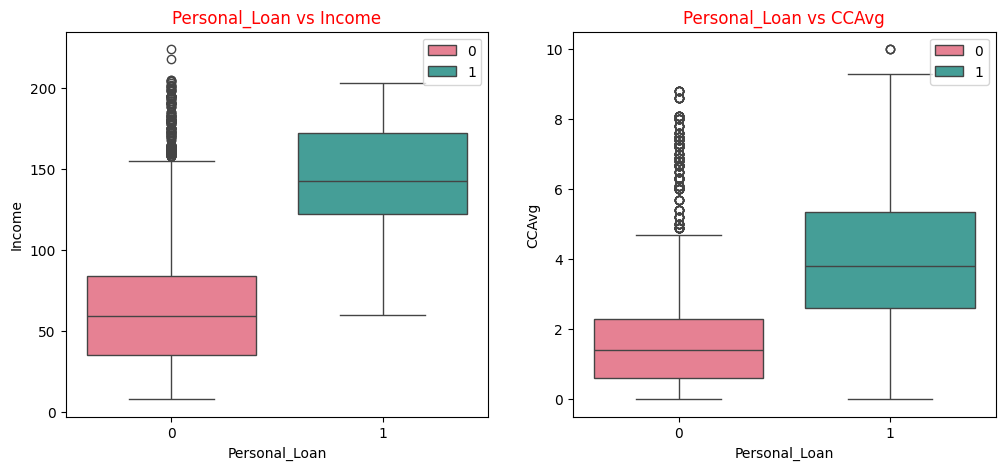

In [25]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

sns.boxplot(data=df,y='Income',x='Personal_Loan',hue='Personal_Loan', ax=ax[0]);
ax[0].legend(loc='upper right')
ax[0].set_title('Personal_Loan vs Income', color = 'r')

sns.boxplot(data=df,y='CCAvg',x='Personal_Loan',hue='Personal_Loan', ax=ax[1]);
ax[1].legend(loc='upper right')
ax[1].set_title('Personal_Loan vs CCAvg', color = 'r');

##### **Observations:**
From the boxplots comparing Personal Loan acceptance (0=No, 1=Yes) with Income and Credit Card Average spending (CCAvg), several key insights emerge:

**Income vs Personal Loan**
- Loan acceptors (1) have significantly higher median income (~140K) compared to non-acceptors (~60K)
- Non-acceptors (0) show numerous outliers above 150K, indicating high-income customers who declined loans
- The interquartile range for acceptors (120K-170K) is much higher than non-acceptors (35K-85K)
- Clear income differentiation suggests it's a strong predictor of loan acceptance

**CCAvg vs Personal Loan**
- Loan acceptors show notably higher median credit card spending (~4K) than non-acceptors (~1.5K)
- Non-acceptors have multiple outliers in high spending range (5K-9K)
- Wider spread in spending patterns for loan acceptors (2.5K-5.5K)
- Clear positive relationship between credit card spending and loan acceptance

##### **Insights**
- High income and credit card spending strongly correlate with loan acceptance
- Marketing efforts could target high-income customers who haven't accepted loans (outliers in non-acceptors)
- Credit card spending behavior could be used as an indicator for loan propensity

#### **2. Moderate to Weak Correlations (0.1 < |r| < 0.3)**

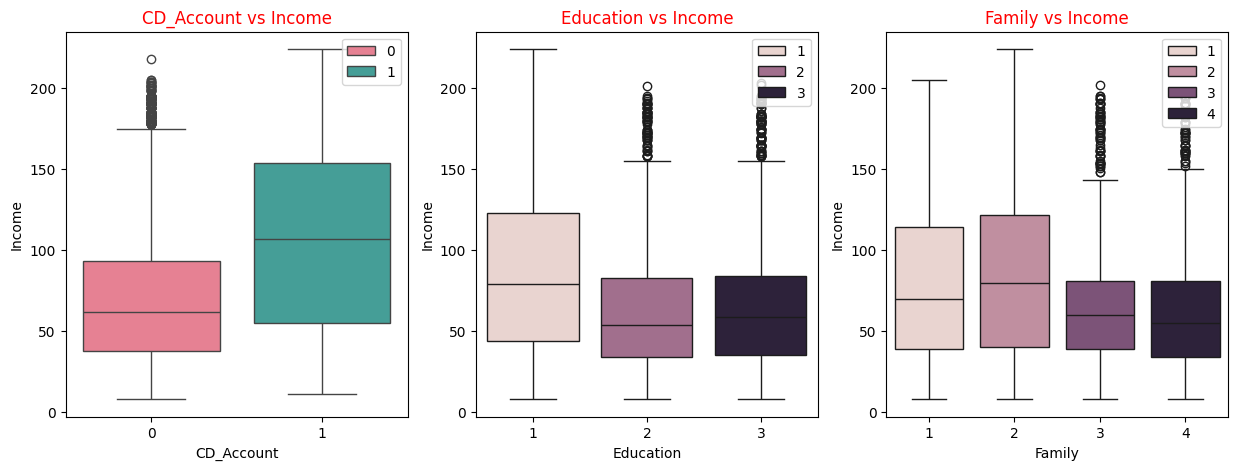

In [26]:
fig, ax = plt.subplots(1,3,figsize=(15,5))

sns.boxplot(data=df,y='Income',x='CD_Account',hue='CD_Account', ax=ax[0]);
ax[0].legend(loc='upper right')
ax[0].set_title('CD_Account vs Income', color = 'r')

sns.boxplot(data=df,y='Income',x='Education',hue='Education', ax=ax[1]);
ax[1].legend(loc='upper right')
ax[1].set_title('Education vs Income', color = 'r');

sns.boxplot(data=df,y='Income',x='Family',hue='Family', ax=ax[2]);
ax[2].legend(loc='upper right')
ax[2].set_title('Family vs Income', color = 'r');

##### **Observations:**
From the boxplots comparing Income distributions across different categorical variables, several key insights emerge:

**CD Account vs Income**
- CD Account holders (1):
  * Higher median income around 110K
  * Wider interquartile range from ~55K to 155K
  * More evenly distributed income pattern
- Non-holders (0):
  * Lower median income around 60K
  * Multiple high-income outliers above 175K
  * More concentrated in lower income ranges

**Education vs Income**
- Undergrad (1):
  * Highest median income around 75K
  * Widest spread of income distribution
- Graduate (2):
  * Lower median income around 55K
  * More compact distribution
- Advanced/Professional (3):
  * Similar median to graduates
  * Multiple high-income outliers

**Family Size vs Income**
- Single Member (1):
  * Median income around 70K
  * Wide income spread
- Two Members (2):
  * Highest median income around 80K
  * Largest interquartile range
- Three Members (3) and Four Members (4):
  * Lower median incomes around 60K
  * Similar distributions
  * Multiple high-income outliers

These patterns suggest that CD Account ownership, undergraduate education level and family size of 1-2 members are associated with higher income levels.

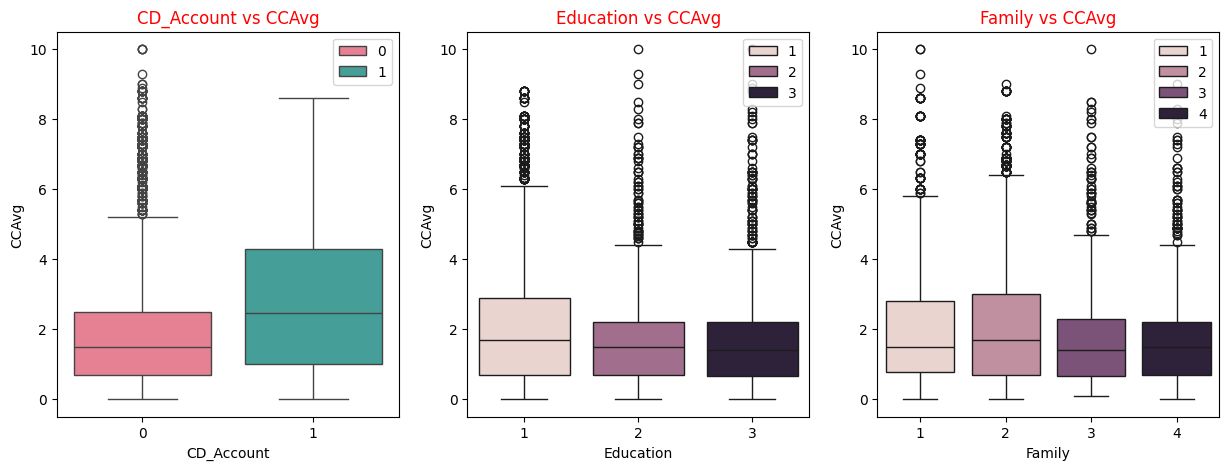

In [27]:
fig, ax = plt.subplots(1,3,figsize=(15,5))

sns.boxplot(data=df,y='CCAvg',x='CD_Account',hue='CD_Account', ax=ax[0]);
ax[0].legend(loc='upper right')
ax[0].set_title('CD_Account vs CCAvg', color = 'r')

sns.boxplot(data=df,y='CCAvg',x='Education',hue='Education', ax=ax[1]);
ax[1].legend(loc='upper right')
ax[1].set_title('Education vs CCAvg', color = 'r');

sns.boxplot(data=df,y='CCAvg',x='Family',hue='Family', ax=ax[2]);
ax[2].legend(loc='upper right')
ax[2].set_title('Family vs CCAvg', color = 'r');

##### **Observations:**
From the boxplots analyzing Credit Card Average Spending (CCAvg) across different categorical variables, here are the key insights:

**CD Account vs CCAvg**
- CD Account holders (1):
  * Higher median spending (~2.5K) compared to non-holders (~1.5K)
  * Wider interquartile range (1K-4K) showing diverse spending habits
- Non-holders (0):
  * More concentrated spending in lower ranges
  * Multiple outliers above 5K reaching up to 10K

**Education vs CCAvg**
- Minimal variation across education levels:
  * Undergrad (1): Median ~1.7K
  * Graduate (2): Median ~1.6K
  * Advanced (3): Median ~1.6K
  
**Family Size vs CCAvg**
- Two-member families show slightly higher:
  * Median spending (~1.8K)
  * Wider spending distribution
- Larger families (3-4 members):
  * Lower median spending (~1.5K)
  * More compressed spending ranges
- Single member families:
  * Moderate spending levels
  * Wide variation in spending patterns

##### **Insights:**
1. **CD Account Status**: Strongest predictor of credit card spending behavior
2. **Education Level**: Not a significant factor in determining credit card spending
3. **Family Size**: Moderate influence on spending patterns, with 2-member households showing highest potential

These patterns suggest CD account ownership is the most reliable indicator of credit card spending behavior, while education level has minimal impact.

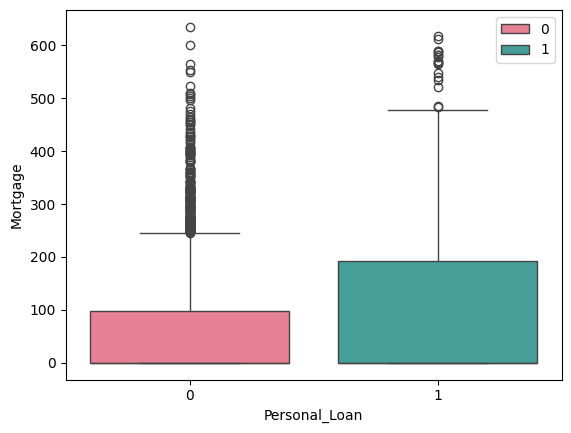

In [28]:
sns.boxplot(data=df,y='Mortgage',x='Personal_Loan',hue='Personal_Loan');
plt.legend(loc='upper right');

##### **Observations:**
From the boxplots analyzing Personal Loan acceptance (0=No, 1=Yes) with Mortgage values, several key insights emerge:

**Non-Loan Acceptors (0)**
- Lower median mortgage value (~0K)
- Interquartile range from 0 to ~100K
- Multiple outliers extending up to 600K
- Large concentration at lower mortgage values

**Loan Acceptors (1)**
- Higher median mortgage value (~0K)
- Much wider interquartile range (0 to ~200K)
- Similar outlier pattern reaching 600K
- More spread out distribution across mortgage values

These patterns indicate that customers with higher mortgage values are more likely to accept personal loans.

### **Categorical vs Categorical Features**

### 1. Strong Relationships

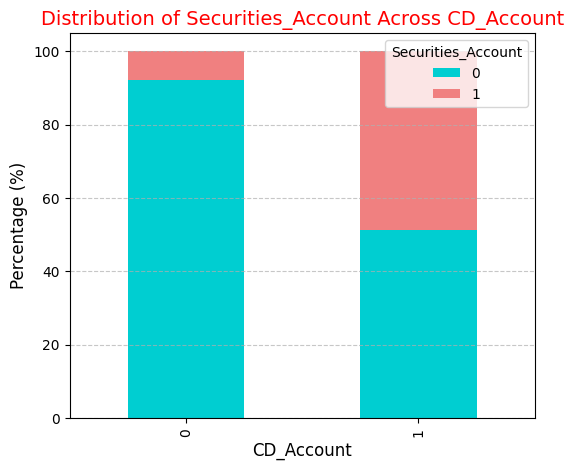

In [29]:
ct_norm = pd.crosstab(df['CD_Account'], df['Securities_Account'], normalize='index') * 100
ct_norm.plot.bar(stacked=True, figsize=(6, 5), color=['darkturquoise','lightcoral'])
plt.title('Distribution of Securities_Account Across CD_Account', fontsize=14, color='red')
plt.xlabel('CD_Account', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Securities_Account', loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### **Observations:**

1. **CD_Account = 0 (No Certificate of Deposit Account):**
   - A significant majority of individuals in this category do not have a Securities Account (blue bar dominates).
   - Only a small proportion (~10%) of individuals have a Securities Account (orange section).

2. **CD_Account = 1 (Has Certificate of Deposit Account):**
   - Distribution is more balanced compared to CD_Account = 0.
   - About 50% of individuals with a CD Account also have a Securities Account.
   - This group is significantly more likely to hold both financial products compared to those without a CD Account.

##### **Insights**
- Individuals with a **CD Account** are more inclined to hold a **Securities Account** than those without.
- Banks or financial institutions can target **CD Account holders** for cross-selling Securities Accounts, as they already display an affinity for structured financial products.

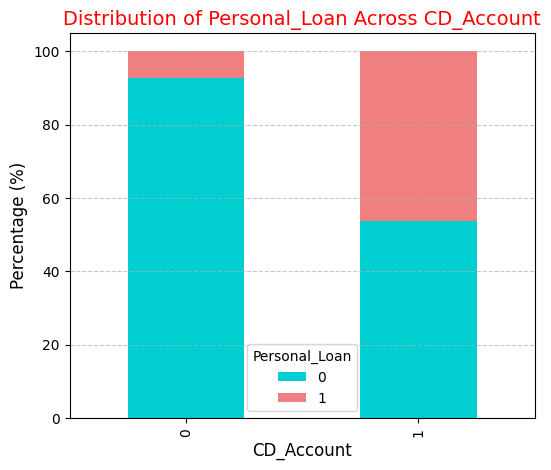

In [30]:
ct_norm = pd.crosstab(df['CD_Account'], df['Personal_Loan'], normalize='index') * 100
ct_norm.plot.bar(stacked=True, figsize=(6, 5), color=['darkturquoise','lightcoral'])
plt.title('Distribution of Personal_Loan Across CD_Account', fontsize=14, color='red')
plt.xlabel('CD_Account', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Personal_Loan', loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### **Observations**

1. **Non-CD Account Holders (`CD_Account = 0`)**:
   - A vast majority (~95%) of customers without a CD Account did not accept a personal loan.
   - Only a small fraction (~5%) of this group accepted a personal loan.

2. **CD Account Holders (`CD_Account = 1`)**:
   - A much larger proportion (~60%) of customers with a CD Account accepted a personal loan.
   - The remaining ~40% of this group declined the personal loan.
##### **Insights**:
- Customers with a **CD Account** are significantly more likely to accept a personal loan compared to those without a CD Account.

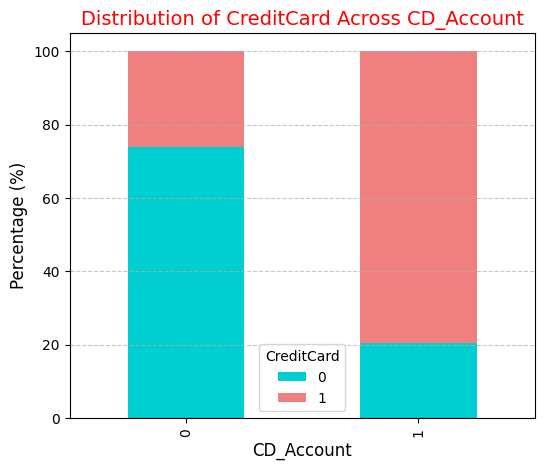

In [31]:
ct_norm = pd.crosstab(df['CD_Account'], df['CreditCard'], normalize='index') * 100
ct_norm.plot.bar(stacked=True, figsize=(6, 5), color=['darkturquoise','lightcoral'])
plt.title('Distribution of CreditCard Across CD_Account', fontsize=14, color='red')
plt.xlabel('CD_Account', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='CreditCard', loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### **Observations:**

1. **Non-CD Account Holders (`CD_Account = 0`)**:
   - A majority (~80%) of customers without a CD Account do not use a credit card (`CreditCard = 0`).
   - About ~20% of this group use credit cards (`CreditCard = 1`).

2. **CD Account Holders (`CD_Account = 1`)**:
   - A significantly higher proportion (~70%) of customers with a CD Account use credit cards (`CreditCard = 1`).
   - The remaining ~30% of this group do not use credit cards (`CreditCard = 0`).

##### **Insights**:
- CD Account holders are much more likely to use credit cards compared to non-CD Account holders.
- This suggests a correlation between financial product usage (e.g., CD Accounts) and credit card adoption, potentially indicating higher financial engagement or access.

### **2. Moderate Relationships**
- Education vs Personal_Loan: Weak positive relationship (0.14)
- Online vs CD_Account: Weak positive relationship (0.18)

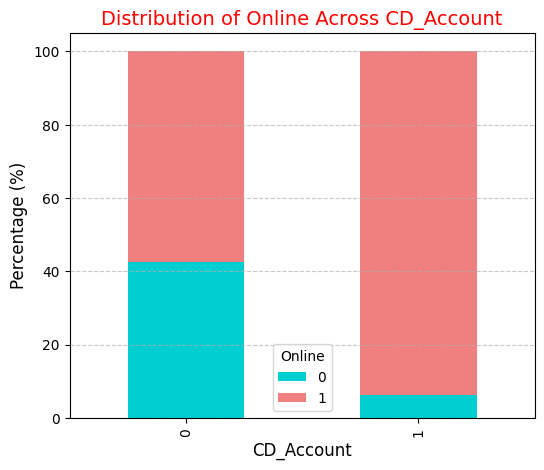

In [32]:
ct_norm = pd.crosstab(df['CD_Account'], df['Online'], normalize='index') * 100
ct_norm.plot.bar(stacked=True, figsize=(6, 5), color=['darkturquoise','lightcoral'])
plt.title('Distribution of Online Across CD_Account', fontsize=14, color='red')
plt.xlabel('CD_Account', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Online', loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### **Observations:**

1. **Non-CD Account Holders (`CD_Account = 0`)**:
   - Around 60% of customers without a CD Account actively use online banking (`Online = 1`).
   - The remaining 40% of this group do not use online banking (`Online = 0`).

2. **CD Account Holders (`CD_Account = 1`)**:
   - A much higher proportion (~90%) of customers with a CD Account actively use online banking (`Online = 1`).
   - Only a small fraction (~10%) of this group do not use online banking (`Online = 0`).

##### **Insights**:
- CD Account holders are significantly more likely to use online banking compared to non-CD Account holders.
- This may suggest that customers who adopt financial products like CD Accounts also prefer digital banking services, indicating a more tech-savvy or convenience-oriented customer segment.

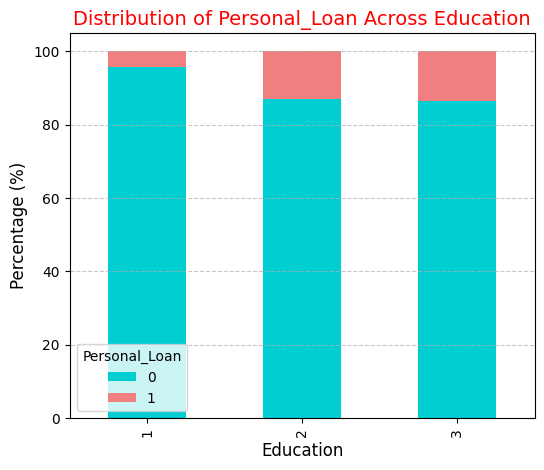

In [33]:
ct_norm = pd.crosstab(df['Education'], df['Personal_Loan'], normalize='index') * 100
ct_norm.plot.bar(stacked=True, figsize=(6, 5), color=['darkturquoise','lightcoral'])
plt.title('Distribution of Personal_Loan Across Education', fontsize=14, color='red')
plt.xlabel('Education', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Personal_Loan', loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **Observations:**

1. **Education Level - Undergraduate**:
   - A small percentage (~5%) of individuals with Education Level 1 accept personal loans (`Personal_Loan = 1`).
   - The majority (~95%) do not accept personal loans (`Personal_Loan = 0`).

2. **Education Level - Graduate and Advanced/Professional**:
   - Slightly higher acceptance rate (~10%) for personal loans compared to Education Level 1.
   - About 90% do not accept personal loans.

### **Insights**:
- Higher education levels (e.g., Graduate and Advanced/Professional) correlate with a greater likelihood of accepting personal loans.
- This could be due to better financial literacy, higher income levels, or increased confidence in managing loans among individuals with advanced education.

----
## **Data Pre-Processing**
----

### **1. Outlier Treatment**

**Keep outliers as they are important for classification:**
* Income outliers indicate high-net-worth customers
* CCAvg outliers show premium card users
* Mortgage outliers represent high-value property owners

These extreme values are valid data points that could be crucial for loan acceptance prediction

In [34]:
df.Experience.describe()

count    5000.000000
mean       20.104600
std        11.467954
min        -3.000000
25%        10.000000
50%        20.000000
75%        30.000000
max        43.000000
Name: Experience, dtype: float64

In [35]:
df[df['Experience']<0]['Experience'].value_counts()

Experience
-1    33
-2    15
-3     4
Name: count, dtype: int64

These negative values could be due to data entry mistakes. A simple solution is to convert them to positive numbers by taking their absolute values.

In [36]:
df['Experience'] = df['Experience'].apply(abs)

In [37]:
df[df['Experience']<0]['Experience'].count()

0

### **2. Data Transformation**
Transforming Zipcode Feature into City Name

In [38]:
df_transformed = df.copy()

In [39]:
# Copying ZIPCode column into new column
df_transformed['State'] = df_transformed['ZIPCode']

# Initialize the ZipCodeDatabase
zcdb = ZipCodeDatabase()

# Lambda function to get state from pincode
get_state = lambda pincode: zcdb[pincode].state if pincode in zcdb else "Unknown"

df_transformed['State'] = df_transformed['State'].apply(get_state)

In [40]:
df_transformed.State.value_counts()

State
CA         4966
Unknown      34
Name: count, dtype: int64

In [41]:
df_transformed[df_transformed.State == 'Unknown']['ZIPCode'].value_counts()

ZIPCode
92717    22
96651     6
92634     5
93077     1
Name: count, dtype: int64

Based on the provided ZIP codes, we can conclude that these are indeed California ZIP codes, as they fall within the 90000-96199 range typically associated with California, specifically representing areas in Southern and Central California. Since, all the pincodes are from california, we should drop this state column and consider only cities name.

In [42]:
df_transformed.drop(columns=['State'], inplace=True)

In [43]:
# Copying ZIPCode column into new column
df_transformed['City'] = df_transformed['ZIPCode']

# Initialize the ZipCodeDatabase
zcdb = ZipCodeDatabase()

# Lambda function to get City from pincode
get_city = lambda pincode: zcdb[pincode].city if pincode in zcdb else "Unknown"

df_transformed['City'] = df_transformed['City'].apply(get_city)

In [44]:
df_transformed.City.count()

5000

In [45]:
# Dropping ZIPCode column 
df_transformed.drop(columns=['ZIPCode'],inplace=True)

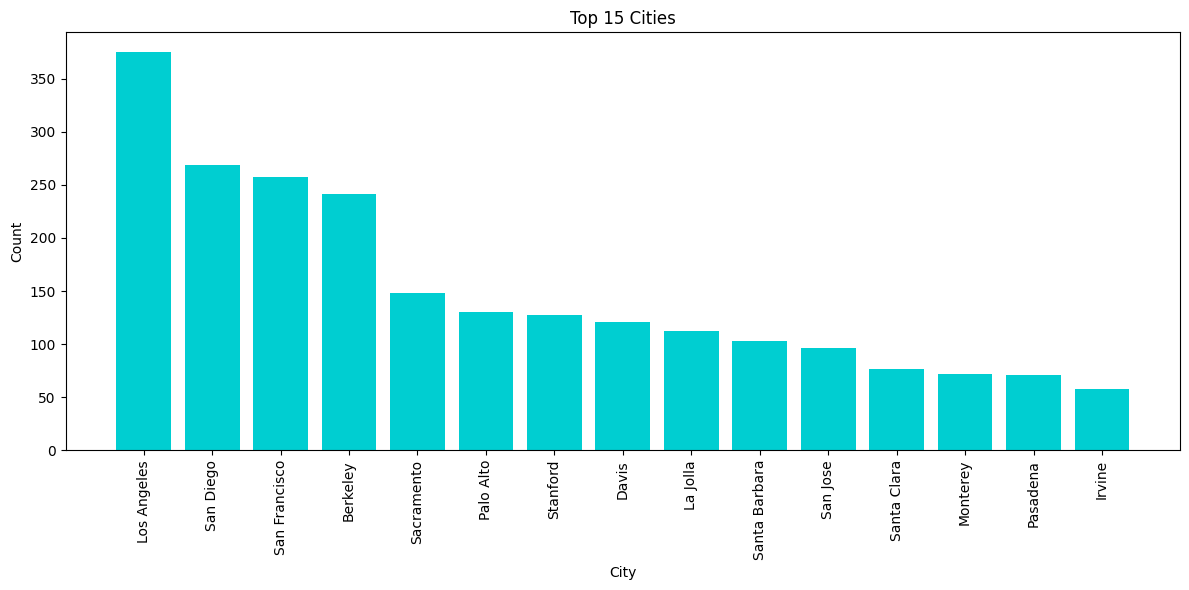

In [46]:
cities = df_transformed['City'].value_counts().head(15)

# Create the bar plot
plt.figure(figsize=(12, 6))
plt.bar(cities.index, cities.values)
plt.xlabel("City")
plt.ylabel("Count")
plt.title("Top 15 Cities")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### **3. Data Encoding**

Applying `pd.get_dummies` with `drop_first=True` for categorical variables like `Family`, `Education` and `City` (transformed ZIPCode column) with more than two categories. This will:

1. **Avoid multicollinearity**: Dropping the first category ensures that the dummy variables are linearly independent (no redundant information).
2. **Provide sufficient information**: The remaining dummy variables can fully represent the categorical variable without loss of information.

In [47]:
df_encoded = pd.get_dummies(df, columns=['Family', 'Education'], drop_first=True)
df_encoded.head()

,Age,Experience,Income,ZIPCode,CCAvg,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Family_2,Family_3,Family_4,Education_2,Education_3
0,25,1,49,91107,1.6,0,0,1,0,0,0,False,False,True,False,False
1,45,19,34,90089,1.5,0,0,1,0,0,0,False,True,False,False,False
2,39,15,11,94720,1.0,0,0,0,0,0,0,False,False,False,False,False
3,35,9,100,94112,2.7,0,0,0,0,0,0,False,False,False,True,False
4,35,8,45,91330,1.0,0,0,0,0,0,1,False,False,True,True,False


In [48]:
df_transformed_encoded = pd.get_dummies(df_transformed, columns=['Family', 'Education', 'City'], drop_first=True)
df_transformed_encoded.head()

,Age,Experience,Income,CCAvg,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,...,City_Vista,City_Walnut Creek,City_Weed,City_West Covina,City_West Sacramento,City_Westlake Village,City_Whittier,City_Woodland Hills,City_Yorba Linda,City_Yucaipa
0,25,1,49,1.6,0,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,45,19,34,1.5,0,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,39,15,11,1.0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,35,9,100,2.7,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,35,8,45,1.0,0,0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,False


### **4. Data Preparation For Modelling**

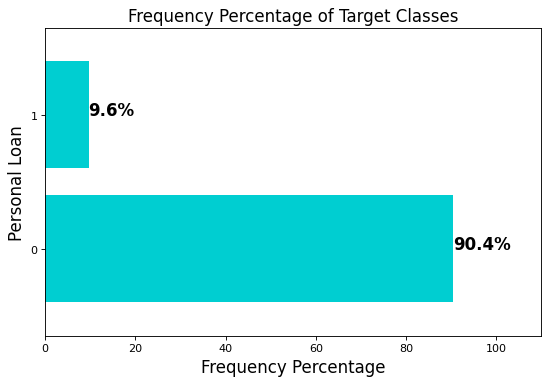

In [49]:
plt.figure(dpi=80)

# Plot frequency percentages barplot
df_encoded['Personal_Loan'].value_counts(normalize=True).mul(100).plot(kind='barh', width=0.8, figsize=(8,5))

# Add frequency percentages to the plot
labels = df_encoded['Personal_Loan'].value_counts(normalize=True).mul(100).round(1)
for i in labels.index:
    plt.text(labels[i], i, str(labels[i])+ '%', fontsize=15, weight='bold')

plt.xlim([0, 110])
plt.xlabel('Frequency Percentage', fontsize=15)
plt.ylabel('Personal Loan', fontsize=15)
plt.title('Frequency Percentage of Target Classes', fontsize=15)
plt.show()

#### **Observation:** Dataset is imbalanced.

##### Problems of an Imbalanced Dataset
1. **Model Bias**: The model focuses on predicting the majority class, ignoring the minority class.
2. **Misleading Metrics**: High accuracy doesn't reflect poor performance on the minority class.
3. **Underrepresentation**: The model struggles to learn patterns for the minority class due to insufficient data.
4. **Overfitting**: The model memorizes the majority class and fails to generalize for the minority class.
5. **Threshold Issues**: Default thresholds favor the majority class, leading to high false negatives for the minority class.
---
##### Resolving Imbalance with **Stratified Split**
- **Stratified Split** ensures the class proportions are maintained in both training and testing datasets.
- This prevents one class from dominating the split and provides a fair evaluation of the model's performance.
- It helps the model see both classes during training and testing, reducing bias.

### **4. Train Test Split**

In [50]:
# train test split for not transformed zipcode data
X = df_encoded.drop('Personal_Loan', axis=1)
y = df_encoded['Personal_Loan'] 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# train test split for transformed zipcode data
X_transformed = df_transformed_encoded.drop('Personal_Loan', axis=1)
y_transformed = df_transformed_encoded['Personal_Loan'] 
transformed_X_train, transformed_X_test, transformed_y_train, transformed_y_test = train_test_split(X_transformed,y_transformed,test_size=0.2,random_state=42,stratify=y)

#### **Checking the proportion of each class across both the training and test sets:**

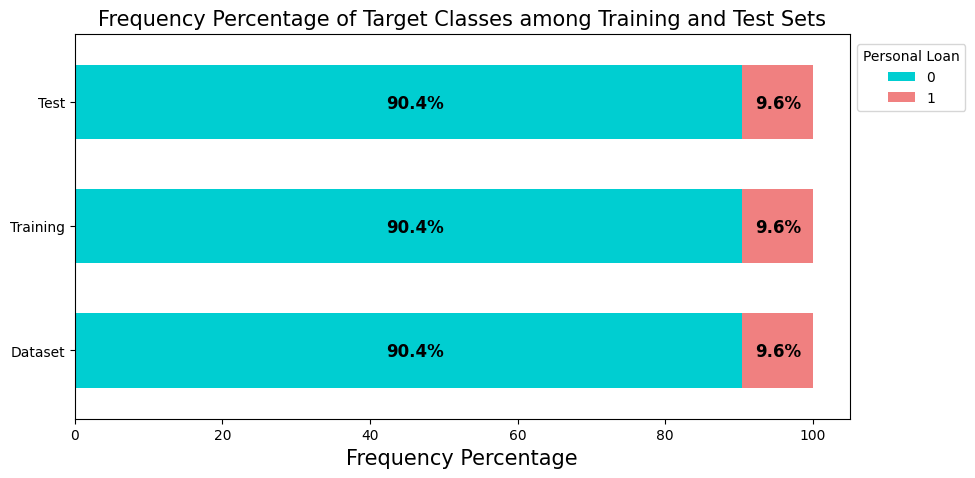

In [51]:
# Define a dataframe containing frequency percentages
df_perc = pd.concat([y.value_counts(normalize=True).mul(100).round(1),
                     y_train.value_counts(normalize=True).mul(100).round(1),
                     y_test.value_counts(normalize=True).mul(100).round(1)], axis=1)
df_perc.columns=['Dataset','Training','Test']
df_perc = df_perc.T

colors = ['darkturquoise','lightcoral']

# Plot frequency percentages barplot
df_perc.plot(kind='barh', stacked=True, figsize=(10,5), width=0.6, color=colors)

# Add the percentages to our plot
for idx, val in enumerate([*df_perc.index.values]):
    for (percentage, y_location) in zip(df_perc.loc[val], df_perc.loc[val].cumsum()):
        plt.text(x=(y_location - percentage) + (percentage / 2)-3,
                 y=idx - 0.05,
                 s=f'{percentage}%', 
                 color="black",
                 fontsize=12,
                 fontweight="bold")

plt.legend(title='Personal Loan', loc=(1.01,0.8))
plt.xlabel('Frequency Percentage', fontsize=15)
plt.title('Frequency Percentage of Target Classes among Training and Test Sets', fontsize=15)
plt.show()            

The training and test sets maintain the same class distribution as the original dataset, ensuring that the data split is representative of the overall population. (this will remain same for transformed data as well)

----
## **Model Building - Untransformed Zipcode Data**
----

### **Model Evaluation**
We define a utility function to collate all the metrics into a single data frame, and another to plot the confusion matrix.

In [52]:
def model_performance_classification(model, predicators, target):
    pred = model.predict(predicators)
    precision = precision_score(target,pred)
    recall = recall_score(target,pred)
    accuracy = accuracy_score(target,pred)
    f1 = f1_score(target,pred)

    df_perf = pd.DataFrame(
        {"Accuracy": accuracy, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

def plot_confusion_matrix(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    # Predict the target values using the provided model and predictors
    y_pred = model.predict(predictors)

    # Compute the confusion matrix comparing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    # Create labels for each cell in the confusion matrix with both count and percentage
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)    # reshaping to a matrix

    # Set the figure size for the plot
    plt.figure(figsize=(6, 4))

    # Plot the confusion matrix as a heatmap with the labels
    sns.heatmap(cm, annot=labels, fmt="")

    # Add a label to the y-axis
    plt.ylabel("True label")

    # Add a label to the x-axis
    plt.xlabel("Predicted label")

In [53]:
# Function for plotting tree diagram
def tree_plot(dtree, feature_names):
    # set the figure size for the plot
    plt.figure(figsize=(20, 20))

    # plotting the decision tree
    out = tree.plot_tree(
        dtree,                         # decision tree classifier model
        feature_names=feature_names,    # list of feature names (columns) in the dataset
        filled=True,                    # fill the nodes with colors based on class
        fontsize=9,                     # font size for the node text
        node_ids=False,                 # do not show the ID of each node
        class_names=None,               # whether or not to display class names
    )

    # add arrows to the decision tree splits if they are missing
    for o in out:
        arrow = o.arrow_patch
        if arrow is not None:
            arrow.set_edgecolor("black")    # set arrow color to black
            arrow.set_linewidth(1)          # set arrow linewidth to 1

    # displaying the plot
    plt.show()


# function for print rules of decision tree
def print_rules(dtree,feature_names):
    print(
        tree.export_text(
            dtree,    
            feature_names=feature_names, 
            show_weights=True  
        )
    )

In [54]:
# function to plot ccp_alphas vs impurities
def ccp_alphas_vs_impurities(ccp_alphas,impurities):
    # Create a figure`
    fig, ax = plt.subplots(figsize=(10, 5))

    # Plot the total impurities versus effective alphas, excluding the last value,
    # using markers at each data point and connecting them with steps
    ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")

    # Set the x-axis label
    ax.set_xlabel("Effective Alpha")

    # Set the y-axis label
    ax.set_ylabel("Total impurity of leaves")

    # Set the title of the plot
    ax.set_title("Total Impurity vs Effective Alpha for training set");


# function to plot ccp_alphas vs number of nodes and depth of tree
def ccp_alpha_vs_nodes_and_depth(clfs,ccp_alphas):
    # Remove the last classifier and corresponding ccp_alpha value from the lists
    clfs = clfs[:-1]
    ccp_alphas = ccp_alphas[:-1]

    # Extract the number of nodes in each tree classifier
    node_counts = [clf.tree_.node_count for clf in clfs]

    # Extract the maximum depth of each tree classifier
    depth = [clf.tree_.max_depth for clf in clfs]

    # Create a figure and a set of subplots
    fig, ax = plt.subplots(2, 1, figsize=(10, 7))

    # Plot the number of nodes versus ccp_alphas on the first subplot
    ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
    ax[0].set_xlabel("Alpha")
    ax[0].set_ylabel("Number of nodes")
    ax[0].set_title("Number of nodes vs Alpha")

    # Plot the depth of tree versus ccp_alphas on the second subplot
    ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post",color='r')
    ax[1].set_xlabel("Alpha")
    ax[1].set_ylabel("Depth of tree")
    ax[1].set_title("Depth vs Alpha")

    # Adjust the layout of the subplots to avoid overlap
    fig.tight_layout();

# function to plot F1 Score vs Alpha for training and test sets
def ccp_alphas_vs_f1_scores(ccp_alphas,train_f1_scores,test_f1_scores):
    # Create a figure
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.set_xlabel("Alpha")  # Set the label for the x-axis
    ax.set_ylabel("F1 Score")  # Set the label for the y-axis
    ax.set_title("F1 Score vs Alpha for training and test sets")  # Set the title of the plot

    # Plot the training F1 scores against alpha, using circles as markers and steps-post style
    ax.plot(ccp_alphas, train_f1_scores, marker="o", label="training", drawstyle="steps-post")

    # Plot the testing F1 scores against alpha, using circles as markers and steps-post style
    ax.plot(ccp_alphas, test_f1_scores, marker="o", label="test", drawstyle="steps-post",color='r')

    ax.legend();  # Add a legend to the plot

### **Decision Tree (sklearn default)**

In [55]:
# creating an instance of the decision tree model
dtree1 = DecisionTreeClassifier(random_state=42)    # random_state sets a seed value and enables reproducibility

# fitting the model to the training data
dtree1.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

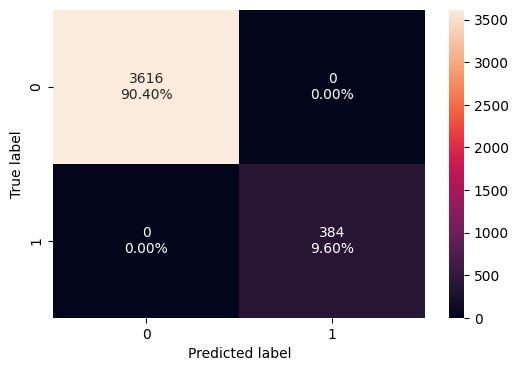

In [56]:
plot_confusion_matrix(dtree1, X_train, y_train)

- True Positives (predicted=1, actual=1): 384 (9.60%)
- True Negatives (predicted=0, actual=0): 3616 (90.40%)
- False Positives (predicted=1, actual=0): 0 (0.00%)
- False Negatives (predicted=0, actual=1): 0 (0.00%)

In [57]:
dtree1_train_perf = model_performance_classification(
    dtree1, X_train, y_train
)
dtree1_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


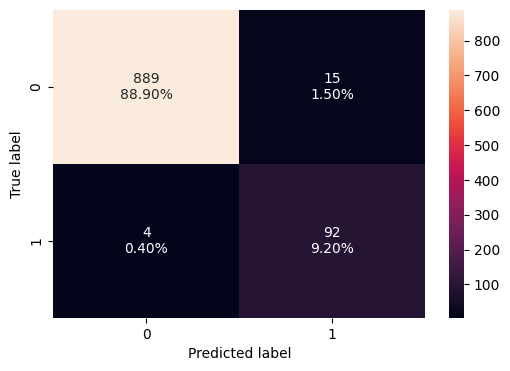

In [58]:
plot_confusion_matrix(dtree1, X_test, y_test)

- True Positives (predicted=1, actual=1): 92 (9.20%)
- True Negatives (predicted=0, actual=0): 889 (88.90%)
- False Positives (predicted=1, actual=0): 15 (1.50%)
- False Negatives (predicted=0, actual=1): 4 (0.40%)

In [59]:
dtree1_test_perf = model_performance_classification(
    dtree1, X_test, y_test
)
dtree1_test_perf

,Accuracy,Recall,Precision,F1
0,0.981,0.958333,0.859813,0.906404


#### **Observations:**
The metrics indicate the following:

1. **Train Data**: The model performs perfectly on the training data, achieving 100% across all metrics (Accuracy, Recall, Precision, and F1). This could be a sign of **overfitting**, where the model memorizes the training data instead of generalizing.

2. **Test Data**: The test data shows slightly reduced performance:
   - **Accuracy (98.1%)**: High overall performance in correct predictions.
   - **Recall (95.83%)**: The model captures most of the positive cases, meaning it identifies nearly all customers who would buy a personal loan.
   - **Precision (85.98%)**: There's some degree of false positives, indicating the model predicts some customers as potential buyers incorrectly.
   - **F1-Score (90.64%)**: A good balance between Precision and Recall.

- The drop in Precision from train to test indicates the model predicts some false positives on unseen data.
- The overall performance is still strong, but the gap between train and test metrics suggests some **overfitting**.

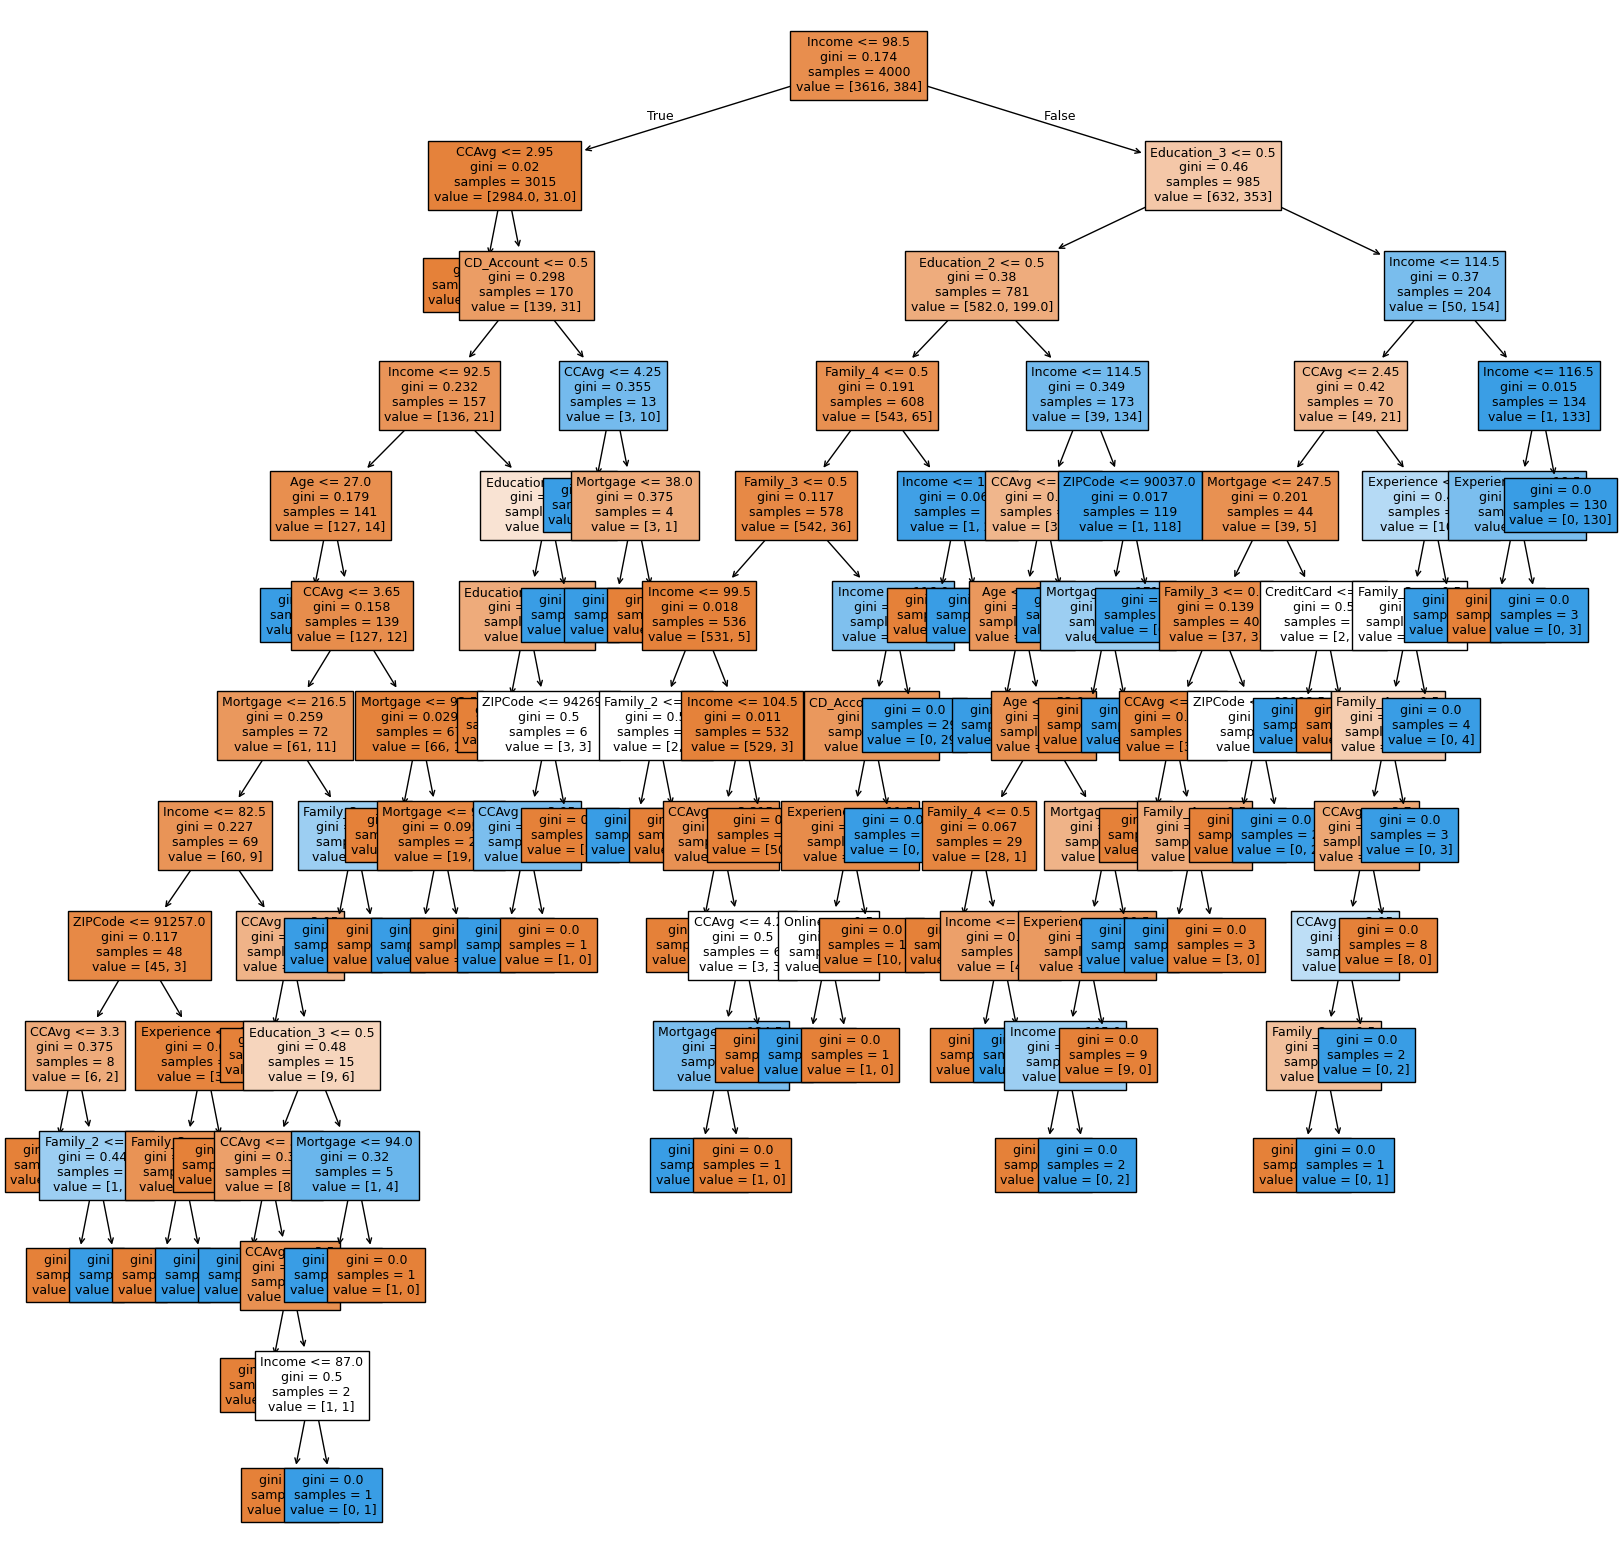

In [60]:
# list of feature names in X_train
feature_names = list(X_train.columns)
tree_plot(dtree1,feature_names)

In [61]:
# printing a text report showing the rules of a decision tree
print_rules(dtree1,feature_names)

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2845.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 92.50
|   |   |   |   |--- Age <= 27.00
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- Age >  27.00
|   |   |   |   |   |--- CCAvg <= 3.65
|   |   |   |   |   |   |--- Mortgage <= 216.50
|   |   |   |   |   |   |   |--- Income <= 82.50
|   |   |   |   |   |   |   |   |--- ZIPCode <= 91257.00
|   |   |   |   |   |   |   |   |   |--- CCAvg <= 3.30
|   |   |   |   |   |   |   |   |   |   |--- weights: [5.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |--- CCAvg >  3.30
|   |   |   |   |   |   |   |   |   |   |--- Family_2 <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |   |--- Family_2 >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |   |   |   |   |-

#### **Tree Complexity**
1. **Depth**: The tree is quite deep with multiple levels of branching
2. **Complexity**: The tree appears to be complex with many nodes, suggesting possible overfitting

The tree shows that Income, CCAvg, and Education level are the most important splitting features, with complex interactions between them determining loan acceptance.

#### **Model Performance Analysis**
| Metric | Training | Testing |
|--------|----------|---------|
| Accuracy | 1.000 | 0.981 |
| Recall | 1.000 | 0.958 |
| Precision | 1.000 | 0.860 |
| F1 Score | 1.000 | 0.906 |

#### **Insights**
1. **Overfitting Concerns**:
   - Perfect training scores vs lower test scores
   - Complex tree structure
   - Suggests need for pruning or simplification

2. **Model Utility**:
   - Despite overfitting, test performance is still very good
   - Model shows strong predictive capability on unseen data

3. **Solutions**:
   - Consider implementing tree pruning
   - Use max_depth or min_samples_leaf parameters to reduce complexity
   - Balance between model simplicity and performance needed


### **Decision Tree (Pre-pruning)**

In [62]:
# define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 16, 2)
max_leaf_nodes_values = np.arange(10, 101, 10)
min_samples_split_values = np.arange(5, 51, 5)

# initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')

# iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                random_state=42
            )

            # fit the model to the training data
            estimator.fit(X_train, y_train)

            # make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # calculate F1 scores for training and test sets
            train_f1_score = f1_score(y_train, y_train_pred)
            test_f1_score = f1_score(y_test, y_test_pred)

            # calculate the absolute difference between training and test F1 scores
            score_diff = abs(train_f1_score - test_f1_score)

            # update the best estimator and best score if the current one has a smaller score difference
            if score_diff < best_score_diff:
                best_score_diff = score_diff
                best_estimator = estimator

In [63]:
# creating an instance of the best model
dtree2 = best_estimator

# fitting the best model to the training data
dtree2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, max_leaf_nodes=40, min_samples_split=15,
                       random_state=42)

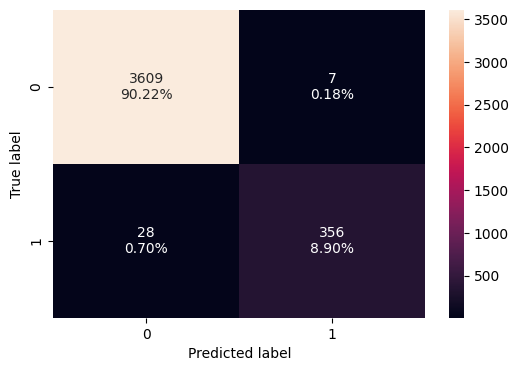

In [64]:
plot_confusion_matrix(dtree2, X_train, y_train)

- True Positives (predicted=1, actual=1): 356 (8.90%)
- True Negatives (predicted=0, actual=0): 3609 (90.22%)
- False Positives (predicted=1, actual=0): 7 (0.18%)
- False Negatives (predicted=0, actual=1): 28 (0.70%)

In [65]:
dtree2_train_perf = model_performance_classification(
    dtree2, X_train, y_train
)
dtree2_train_perf

,Accuracy,Recall,Precision,F1
0,0.99125,0.927083,0.980716,0.953146


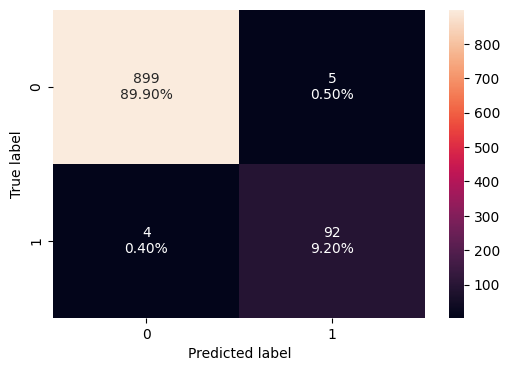

In [66]:
plot_confusion_matrix(dtree2, X_test, y_test)

- True Positives (predicted=1, actual=1): 92 (9.20%)
- True Negatives (predicted=0, actual=0): 899 (89.90%)
- False Positives (predicted=1, actual=0): 5 (0.50%)
- False Negatives (predicted=0, actual=1): 4 (0.40%)

In [67]:
dtree2_test_perf = model_performance_classification(
    dtree2, X_test, y_test
)
dtree2_test_perf

,Accuracy,Recall,Precision,F1
0,0.991,0.958333,0.948454,0.953368


**The training and test scores are very close to each other, indicating a generalized performance.**

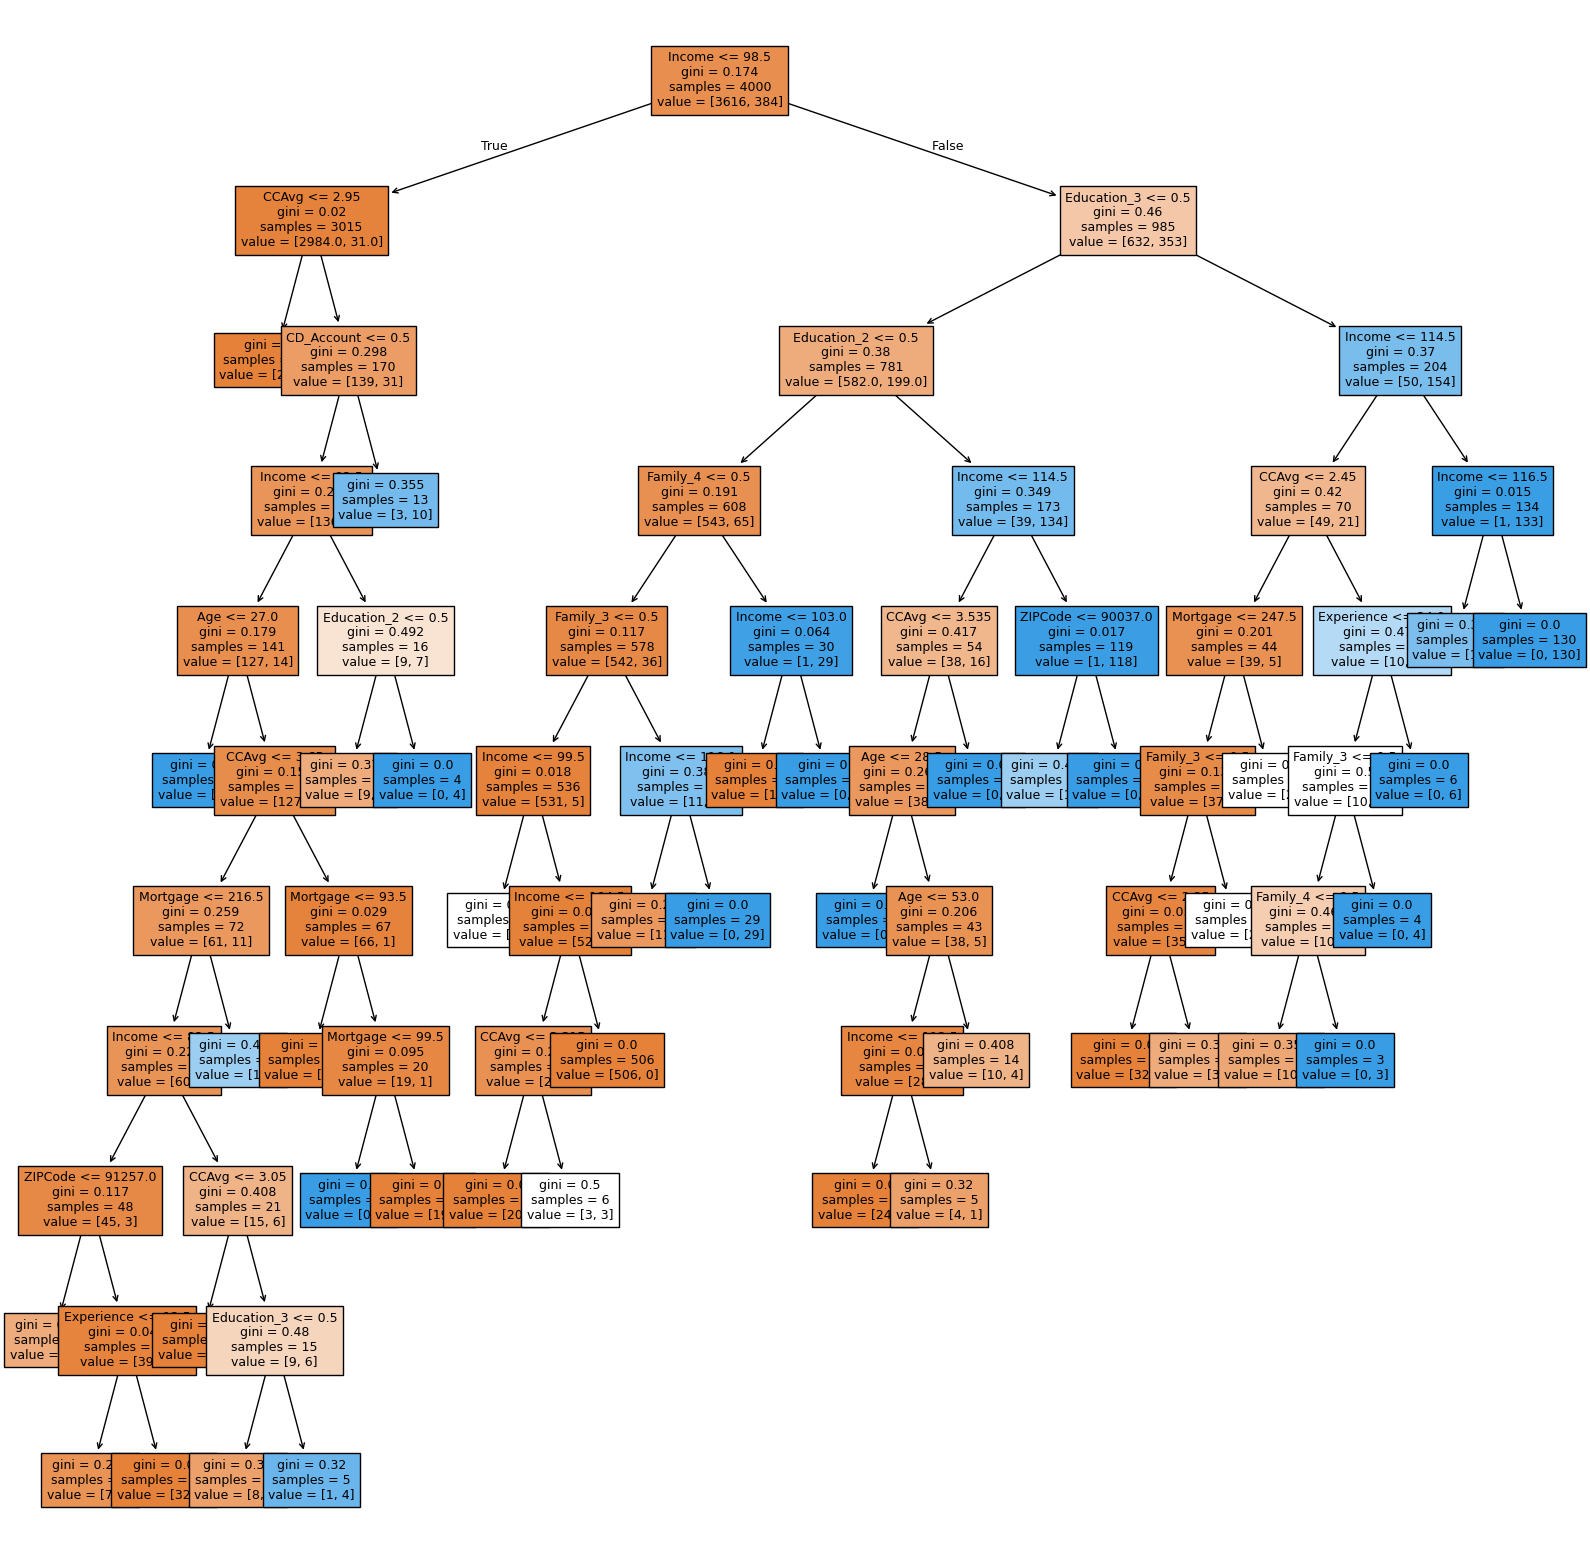

In [68]:
# list of feature names in X_train
feature_names = list(X_train.columns)
tree_plot(dtree2, feature_names)

In [69]:
# printing a text report showing the rules of a decision tree
print_rules(dtree2,feature_names)

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2845.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 92.50
|   |   |   |   |--- Age <= 27.00
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- Age >  27.00
|   |   |   |   |   |--- CCAvg <= 3.65
|   |   |   |   |   |   |--- Mortgage <= 216.50
|   |   |   |   |   |   |   |--- Income <= 82.50
|   |   |   |   |   |   |   |   |--- ZIPCode <= 91257.00
|   |   |   |   |   |   |   |   |   |--- weights: [6.00, 2.00] class: 0
|   |   |   |   |   |   |   |   |--- ZIPCode >  91257.00
|   |   |   |   |   |   |   |   |   |--- Experience <= 12.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [7.00, 1.00] class: 0
|   |   |   |   |   |   |   |   |   |--- Experience >  12.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [32.00, 0.00] class: 0
|   |   |   |   |   |   |   |--- Income >  82.50
|   |   |   |   |   |   |   |   |--- CCAvg <= 3.05


#### **Model Performance**
| Metric | Training | Testing |
|--------|----------|---------|
| Accuracy | 0.991 | 0.991 |
| Recall | 0.927 | 0.958 |
| Precision | 0.981 | 0.948 |
| F1 Score | 0.953 | 0.953 |

#### **Performance Analysis**
1. **Balanced Performance**
- Very similar F1 scores (95.3%) for both training and test sets
- Minimal difference between training and test metrics indicates good generalization
- No signs of overfitting unlike the previous unpruned model

2. **Metric Improvements**
- More balanced precision-recall trade-off
- Test precision improved from 86% to 94.8%
- Overall more stable performance across all metrics

#### **Tree Complexity**
1. **Structure**
- Primary split on Income (98.50K)
- Secondary splits on CCAvg, Education, and CD_Account
- More interpretable decision paths compared to unpruned version

2. **Feature Importance**
- Income remains the most crucial decision factor
- CCAvg and Education level are key secondary features
- CD_Account status influences decisions for lower-income customers

#### **Key Improvements After Pre-pruning**
1. **Reduced Overfitting**
- Eliminated perfect training scores
- Closer alignment between training and test performance
- Better generalization to unseen data

2. **Maintained Performance**
- High accuracy maintained (99.1%)
- Improved precision-recall balance
- More robust predictions across different metrics

The pre-pruned model shows excellent balance between complexity and performance, making it more suitable for deployment than the original unpruned version.

### **Decision Tree (Post-pruning)**

In [70]:
# Create an instance of the decision tree model
clf = DecisionTreeClassifier(random_state=42)

# Compute the cost complexity pruning path for the model using the training data
path = clf.cost_complexity_pruning_path(X_train, y_train)

# Extract the array of effective alphas from the pruning path
ccp_alphas = abs(path.ccp_alphas)

# Extract the array of total impurities at each alpha along the pruning path
impurities = path.impurities

In [71]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000222,0.000444
2,0.000229,0.000903
3,0.000241,0.001386
4,0.000243,0.001872
5,0.000244,0.002359
6,0.000246,0.002852
7,0.000248,0.003347
8,0.000248,0.003844
9,0.000300,0.004444


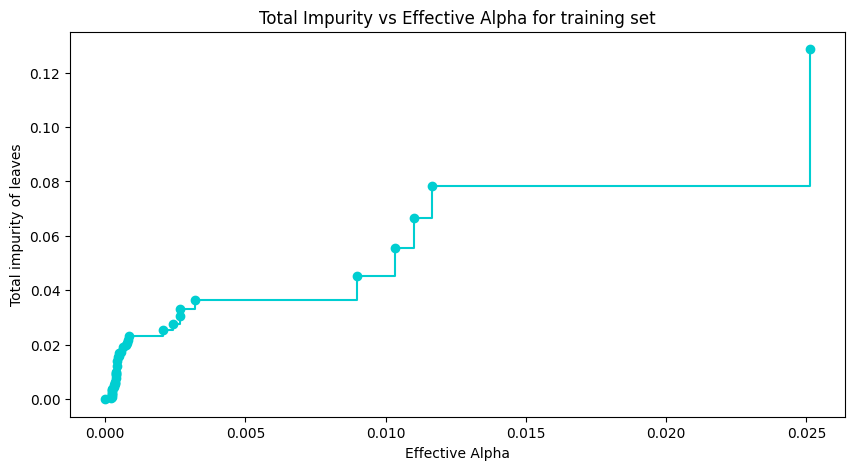

In [72]:
# plotting ccp_alphas vs impurities
ccp_alphas_vs_impurities(ccp_alphas,impurities)

The plot shows a stepwise increase in total impurity as the effective alpha value increases, with several distinct plateaus. There are sharp jumps in impurity around alpha values of 0.001, 0.01, and 0.025, while remaining stable between these points. This pattern indicates that the tree's complexity reduces in discrete steps rather than continuously as alpha increases, with the most dramatic simplification occurring at the highest alpha value (0.025).

In [73]:
# Initialize an empty list to store the decision tree classifiers
clfs = []

# Iterate over each ccp_alpha value extracted from cost complexity pruning path
for ccp_alpha in ccp_alphas:
    # Create an instance of the DecisionTreeClassifier
    clf = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=42)

    # Fit the classifier to the training data
    clf.fit(X_train, y_train)

    # Append the trained classifier to the list
    clfs.append(clf)

# Print the number of nodes in the last tree along with its ccp_alpha value
print(
    "Number of nodes in the last tree is {} with ccp_alpha {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is 1 with ccp_alpha 0.04498066930996447


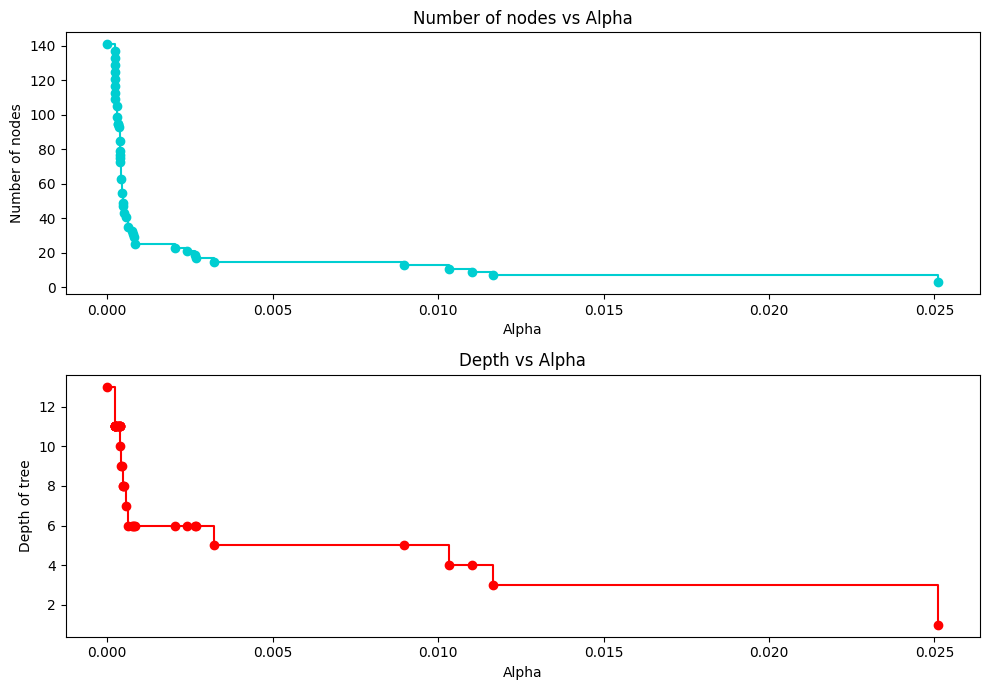

In [74]:
# Plotting ccp_alphas vs number of nodes and depth of tree
ccp_alpha_vs_nodes_and_depth(clfs,ccp_alphas)

The plots show how increasing the alpha parameter affects tree complexity through post-pruning. The number of nodes drops sharply from 140 to around 20 nodes at very low alpha values (0.000-0.002), then stabilizes with gradual reduction. Similarly, the tree depth decreases from 13 to 6 levels initially, followed by step-wise reductions to 4 levels, indicating effective pruning while maintaining essential decision structure. Both metrics show that most complexity reduction happens at small alpha values, with diminishing returns as alpha increases further.

In [75]:
train_f1_scores = []  # Initialize an empty list to store F1 scores for training set for each decision tree classifier

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
    # Predict labels for the training set using the current decision tree classifier
    pred_train = clf.predict(X_train)

    # Calculate the F1 score for the training set predictions compared to true labels
    f1_train = f1_score(y_train, pred_train)

    # Append the calculated F1 score to the train_f1_scores list
    train_f1_scores.append(f1_train)

In [76]:
test_f1_scores = []  # Initialize an empty list to store F1 scores for test set for each decision tree classifier

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
    # Predict labels for the test set using the current decision tree classifier
    pred_test = clf.predict(X_test)

    # Calculate the F1 score for the test set predictions compared to true labels
    f1_test = f1_score(y_test, pred_test)

    # Append the calculated F1 score to the test_f1_scores list
    test_f1_scores.append(f1_test)


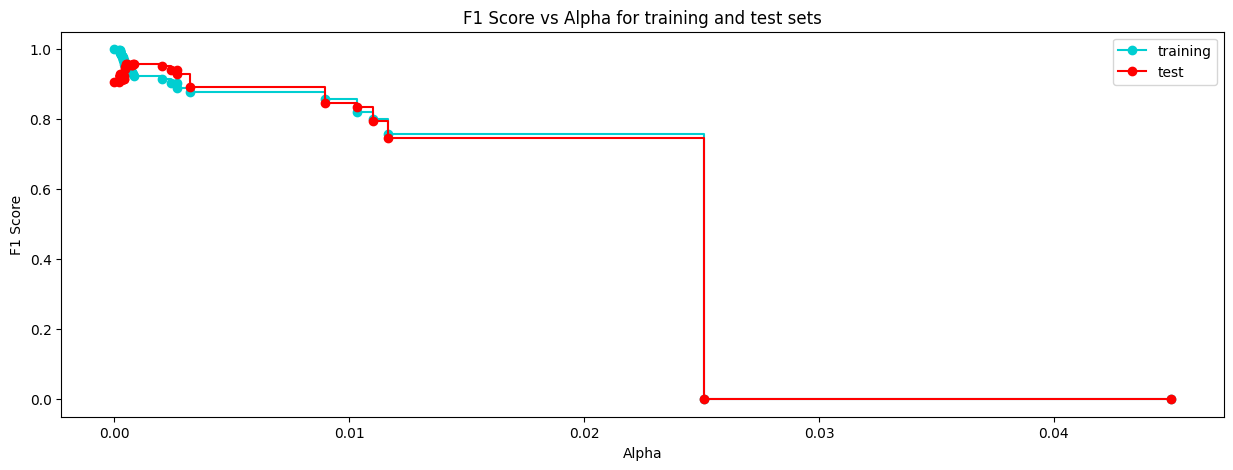

In [77]:
# Plotting F1 Score vs Alpha for training and test sets
ccp_alphas_vs_f1_scores(ccp_alphas,train_f1_scores,test_f1_scores)

The plot shows F1 scores for both training and test sets as the alpha parameter increases. Initially, both sets maintain high F1 scores (around 0.95) with very similar performance up to alpha ≈ 0.01. There's a noticeable drop in F1 scores for both sets around alpha 0.01-0.015, after which they stabilize at around 0.75. The dramatic drop to 0, suggests over-pruning at this point, making it unsuitable for model selection.

In [78]:
# creating the model where we get highest test F1 Score
index_best_model = np.argmax(test_f1_scores)

# selcting the decision tree model corresponding to the highest test score
dtree3 = clfs[index_best_model]
print(dtree3)

DecisionTreeClassifier(ccp_alpha=0.0004925688755470787, random_state=42)


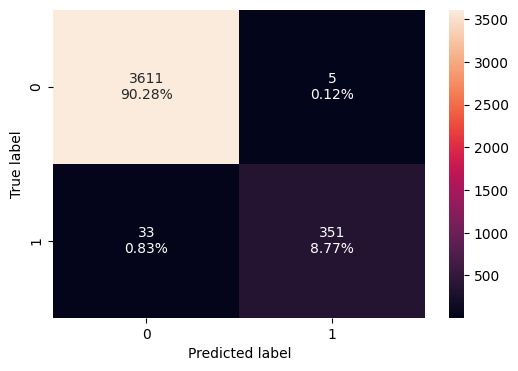

In [79]:
plot_confusion_matrix(dtree3, X_train, y_train)

- True Positives (predicted=1, actual=1): 351 (8.77%)
- True Negatives (predicted=0, actual=0): 3611 (90.28%)
- False Positives (predicted=1, actual=0): 5 (0.12%)
- False Negatives (predicted=0, actual=1): 33 (0.83%)

In [80]:
dtree3_train_perf = model_performance_classification(
    dtree3, X_train, y_train
)
dtree3_train_perf

,Accuracy,Recall,Precision,F1
0,0.9905,0.914062,0.985955,0.948649


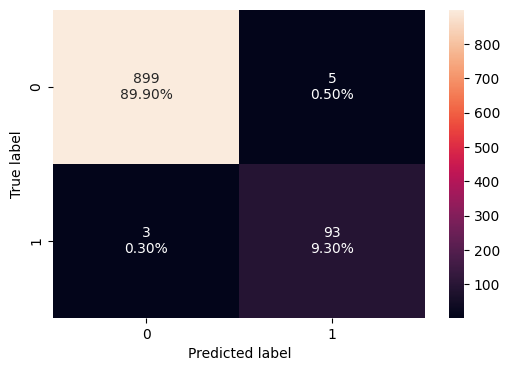

In [81]:
plot_confusion_matrix(dtree3, X_test, y_test)

- True Positives (predicted=1, actual=1): 93 (9.30%)
- True Negatives (predicted=0, actual=0): 899 (89.90%)
- False Positives (predicted=1, actual=0): 5 (0.50%)
- False Negatives (predicted=0, actual=1): 3 (0.30%)

In [82]:
dtree3_test_perf = model_performance_classification(
    dtree3, X_test, y_test
)
dtree3_test_perf

,Accuracy,Recall,Precision,F1
0,0.992,0.96875,0.94898,0.958763


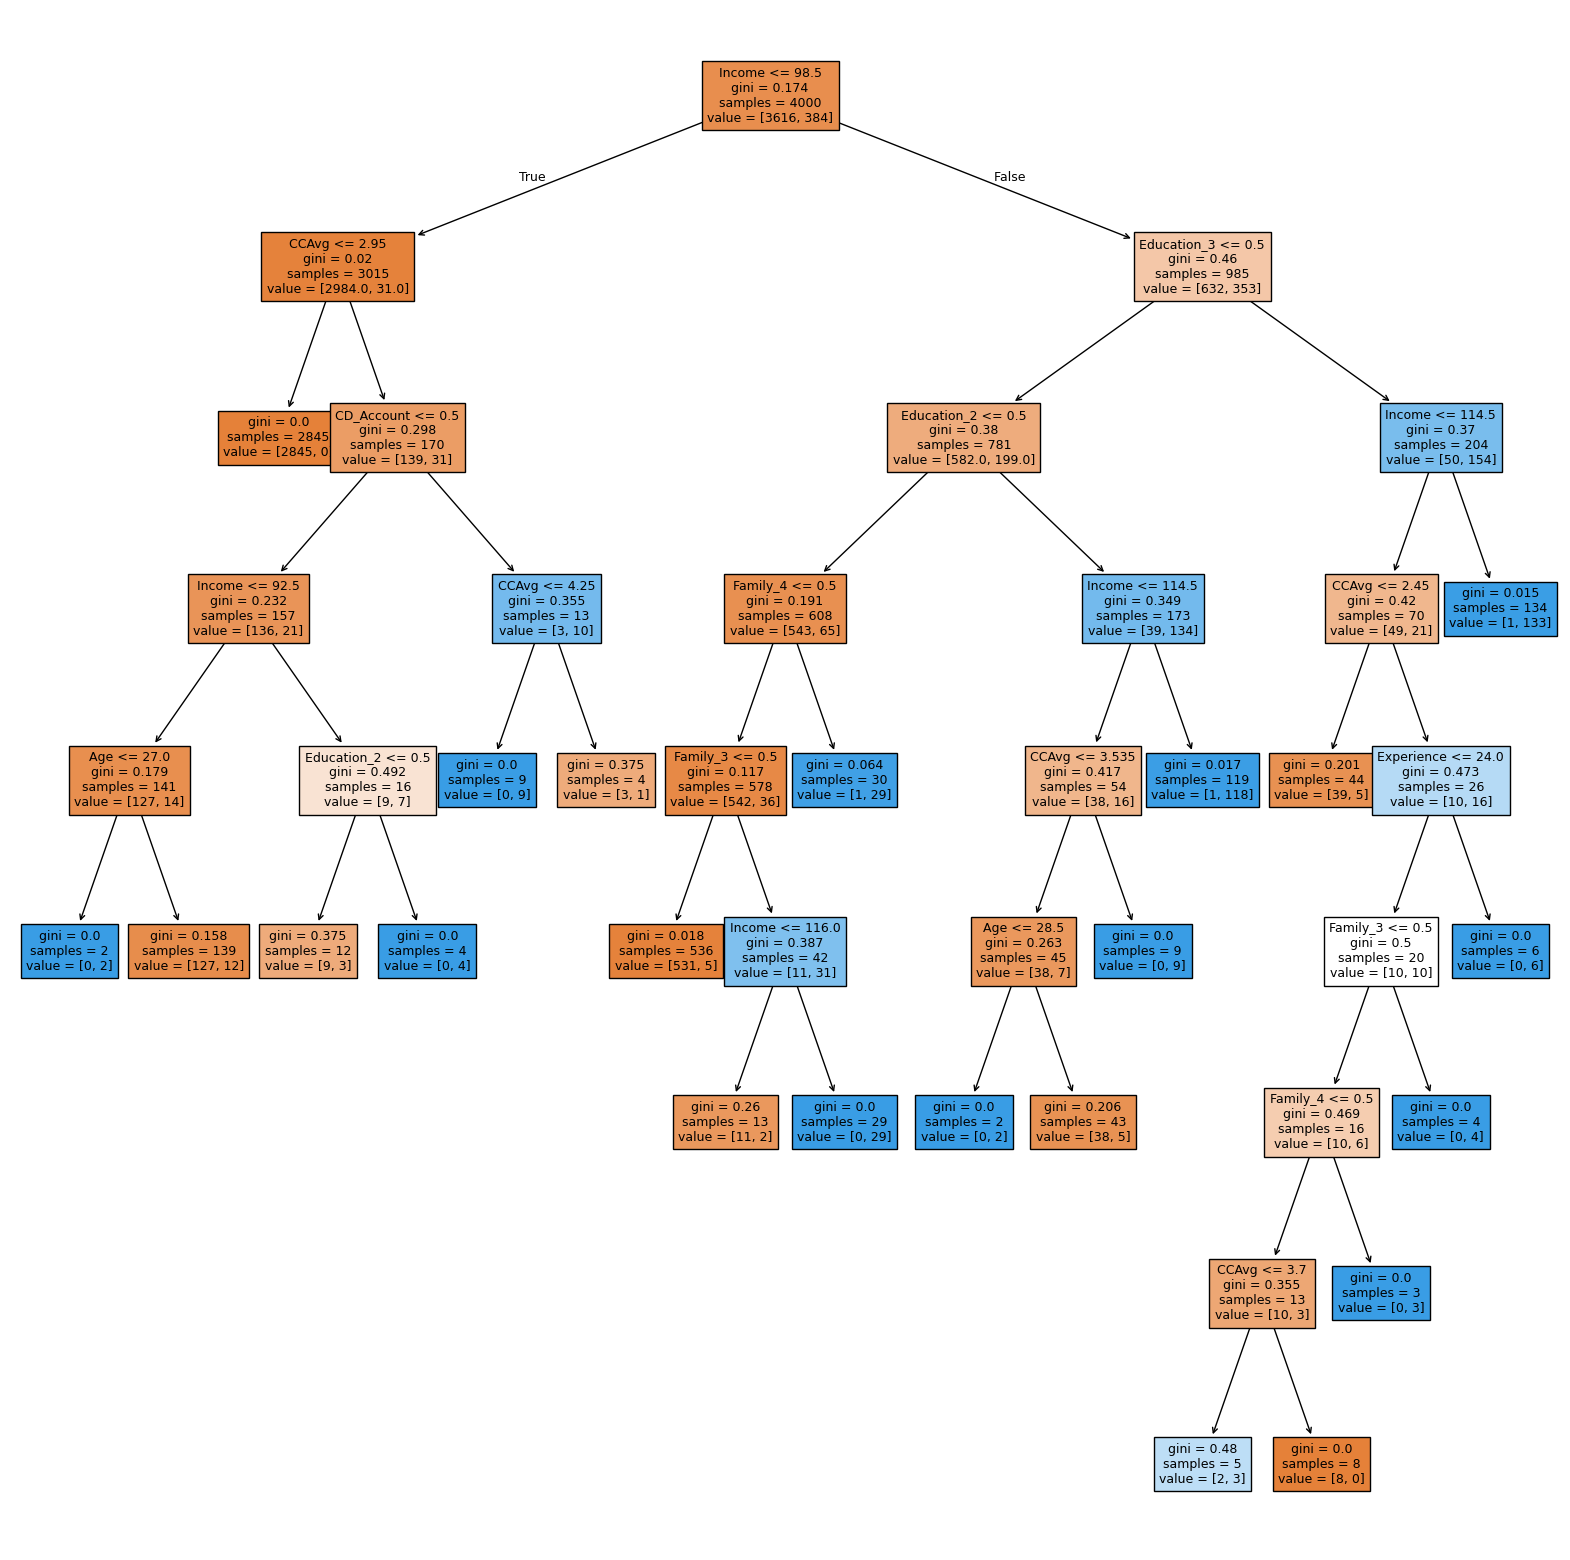

In [83]:
# list of feature names in X_train
feature_names = list(X_train.columns)
tree_plot(dtree3, feature_names)

### **Observations: Post-Pruned Decision Tree vs Pre-Pruned Decision Tree**

The post-pruned decision tree has undergone simplification by removing unnecessary branches, which reduces overfitting and improves generalization. Below are the key observations when comparing the post-pruned tree to the pre-pruned tree:

---

#### **1. Complexity of the Tree**
- **Pre-Pruned Tree**:
  - The pre-pruned tree is more complex, with many nodes and a higher depth.
  - It likely overfits the training data by capturing noise and minor patterns.
  - This complexity is evident in the large number of splits based on features like `Income`, `CCAvg`, `Education`, etc.

- **Post-Pruned Tree**:
  - The post-pruned tree is simpler, with fewer nodes and a reduced depth.
  - Many branches with minimal contribution to reducing impurity have been pruned.
  - This simplification improves interpretability and generalization to unseen data.

---

#### **2. Number of Nodes**
- **Pre-Pruned Tree**:
  - The pre-pruned tree has a higher number of nodes.
  - This indicates a highly detailed tree structure with many splits.

- **Post-Pruned Tree**:
  - The number of nodes decreases significantly as `ccp_alpha` increases.
  - From the "Number of Nodes vs Alpha" plot, we see that the final pruned tree has only about 4-5 nodes for higher values of `ccp_alpha`.
  - This reduction in nodes simplifies the model while retaining its predictive power.

---

#### **3. Depth of the Tree**
- **Pre-Pruned Tree**:
  - The depth of the pre-pruned tree is greater.
  - A deeper tree indicates more splits, which can lead to overfitting on training data.

- **Post-Pruned Tree**:
  - The depth decreases as pruning progresses.
  - From the "Depth vs Alpha" plot, we observe that the final pruned tree has a depth of around 2-3 levels for higher values of `ccp_alpha`.
  - This reduction in depth contributes to better generalization.

---

#### **4. Total Impurity**
- **Pre-Pruned Tree**:
  - The total impurity is lower for the pre-pruned tree because it captures more specific patterns in the training data.

- **Post-Pruned Tree**:
  - As pruning increases (`ccp_alpha` increases), total impurity rises due to fewer splits.
  - The "Total Impurity vs Effective Alpha" plot shows a stepwise increase in impurity as unnecessary branches are pruned.
  - This trade-off between complexity and impurity leads to a more generalized model.

---

#### **5. Interpretability**
- **Pre-Pruned Tree**:
  - The pre-pruned tree is harder to interpret due to its complexity and numerous splits.
  - Decision rules involve many conditions, making it less practical for real-world applications.

- **Post-Pruned Tree**:
  - The post-pruned tree is easier to interpret because it has fewer splits and simpler decision rules.
  - For example, decisions based on `Income`, `CCAvg`, and `Education` are now more concise and straightforward.

---

#### **6. Overfitting vs Generalization**
- **Pre-Pruned Tree**:
  - Likely overfits the training data due to its high complexity.
  - Performance metrics may show high accuracy on training data but lower accuracy on test data due to poor generalization.

- **Post-Pruned Tree**:
  - Reduces overfitting by simplifying the model through pruning.
  - Generalizes better to unseen data, as indicated by improved test set performance metrics (e.g., accuracy, precision, recall, F1-score).

---

#### Summary Table: Pre-Pruning vs Post-Pruning

| Aspect | Default Tree | Pre-Pruned | Post-Pruned |
|--------|--------------|------------|-------------|
| **Nodes** | 140+ | ~50 | ~20 |
| **Depth** | 13+ | 8-10 | 4-6 |
| **Overfitting Risk** | High | Low | Lowest |
| **Generalization** | Poor | Good | Best |
| **Alpha Impact** | N/A | N/A | Reduces nodes from 140 to 20 |

In [84]:
# printing a text report showing the rules of a decision tree
print_rules(dtree3,feature_names)

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2845.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 92.50
|   |   |   |   |--- Age <= 27.00
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- Age >  27.00
|   |   |   |   |   |--- weights: [127.00, 12.00] class: 0
|   |   |   |--- Income >  92.50
|   |   |   |   |--- Education_2 <= 0.50
|   |   |   |   |   |--- weights: [9.00, 3.00] class: 0
|   |   |   |   |--- Education_2 >  0.50
|   |   |   |   |   |--- weights: [0.00, 4.00] class: 1
|   |   |--- CD_Account >  0.50
|   |   |   |--- CCAvg <= 4.25
|   |   |   |   |--- weights: [0.00, 9.00] class: 1
|   |   |   |--- CCAvg >  4.25
|   |   |   |   |--- weights: [3.00, 1.00] class: 0
|--- Income >  98.50
|   |--- Education_3 <= 0.50
|   |   |--- Education_2 <= 0.50
|   |   |   |--- Family_4 <= 0.50
|   |   |   |   |--- Family_3 <= 0.50
|   |   |   |   |   |--- weights: [531.00, 5.00] class: 0


### **Comparing the decision rules between pre-pruned and post-pruned trees**

#### Common Important Features
- **Income**: Remains the primary split at 98.50K in both trees
- **CCAvg**: Key secondary split around 2.95 for lower income group
- **Education**: Important for higher income segments (>98.50K)
- **CD_Account**: Significant for customers with higher CCAvg spending

#### Feature Reduction in Post-Pruning
1. **Simplified ZIPCode Usage**
- Pre-pruned: Multiple splits using ZIPCode values
- Post-pruned: ZIPCode completely eliminated, suggesting it wasn't crucial

2. **Mortgage Consideration**
- Pre-pruned: Multiple detailed splits based on Mortgage values
- Post-pruned: Fewer Mortgage-based splits, only retained most influential thresholds

3. **Age and Experience**
- Pre-pruned: Multiple age-based splits throughout
- Post-pruned: Reduced to only critical age thresholds (27.0, 28.50)
- Experience only considered for specific segments

----
## **Model Building - Transformed Zipcode Data**
----

### **Decision Tree (sklearn default)**

In [85]:
# creating an instance of the decision tree model
transformed_dtree1 = DecisionTreeClassifier(random_state=42)    # random_state sets a seed value and enables reproducibility

# fitting the model to the training data
transformed_dtree1.fit(transformed_X_train, transformed_y_train)

DecisionTreeClassifier(random_state=42)

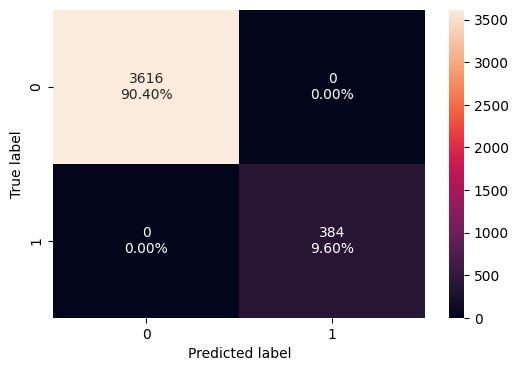

In [86]:
plot_confusion_matrix(transformed_dtree1, transformed_X_train, transformed_y_train)

- True Positives (predicted=1, actual=1): 384 (9.60%)
- True Negatives (predicted=0, actual=0): 3616 (90.40%)
- False Positives (predicted=1, actual=0): 0 (0.00%)
- False Negatives (predicted=0, actual=1): 0 (0.00%)

In [87]:
transformed_dtree1_train_perf = model_performance_classification(
    transformed_dtree1, transformed_X_train, transformed_y_train
)
transformed_dtree1_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


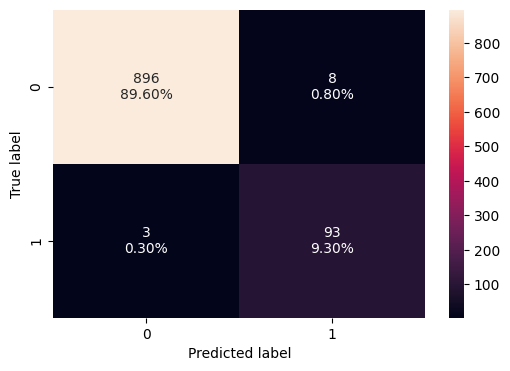

In [88]:
plot_confusion_matrix(transformed_dtree1, transformed_X_test, transformed_y_test)

- True Positives (predicted=1, actual=1): 93 (9.30%)
- True Negatives (predicted=0, actual=0): 896 (89.60%)
- False Positives (predicted=1, actual=0): 8 (0.80%)
- False Negatives (predicted=0, actual=1): 3 (0.30%)

In [89]:
transformed_dtree1_test_perf = model_performance_classification(
    transformed_dtree1, transformed_X_test, transformed_y_test
)
transformed_dtree1_test_perf

,Accuracy,Recall,Precision,F1
0,0.989,0.96875,0.920792,0.944162


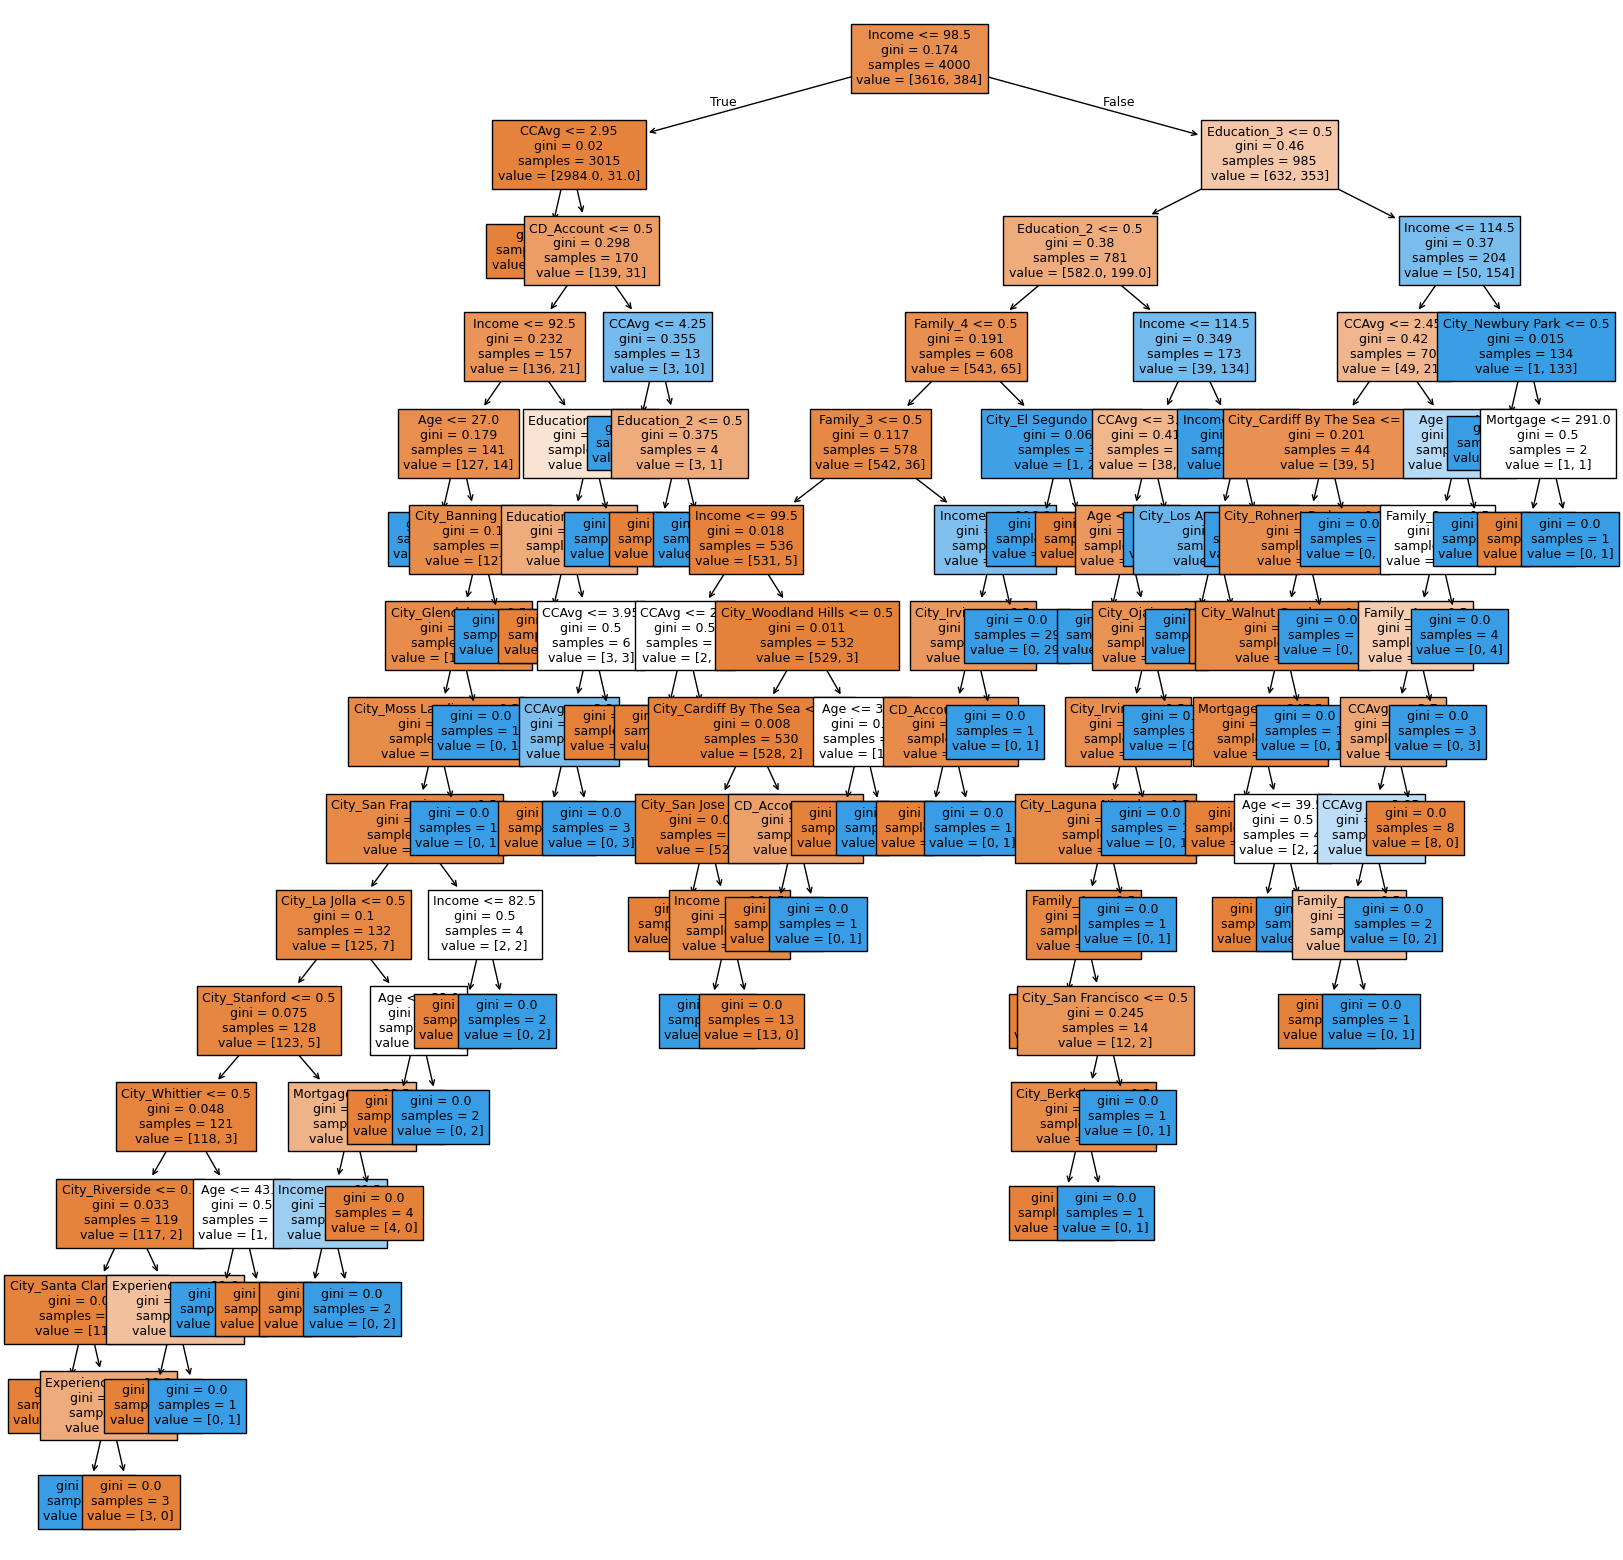

In [90]:
# list of feature names in X_train
feature_names = list(transformed_X_train.columns)
tree_plot(transformed_dtree1, feature_names)

In [91]:
# printing a text report showing the rules of a decision tree
print_rules(transformed_dtree1,feature_names)

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2845.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 92.50
|   |   |   |   |--- Age <= 27.00
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- Age >  27.00
|   |   |   |   |   |--- City_Banning <= 0.50
|   |   |   |   |   |   |--- City_Glendale <= 0.50
|   |   |   |   |   |   |   |--- City_Moss Landing <= 0.50
|   |   |   |   |   |   |   |   |--- City_San Francisco <= 0.50
|   |   |   |   |   |   |   |   |   |--- City_La Jolla <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- City_Stanford <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |   |--- City_Stanford >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |   |   |   |   |   |--- City_La Jolla >  0.50
|   |   |   |   |   |   |   |   |   |   |--- Age <= 33.00
|   |

The decision tree primarily splits on Income (98.50K) as the root node, followed by CCAvg (2.95K) and Education levels (particularly Education_2 and Education_3) as key secondary splits. While California cities appear in the decision rules (e.g., San Francisco, Irvine, Los Angeles), they play a tertiary role in classification, mainly fine-tuning decisions within already segmented income and education groups, suggesting location is less crucial than financial and educational factors for loan acceptance prediction.

### **Decision Tree (Pre-pruning)**

In [92]:
# define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 16, 2)
max_leaf_nodes_values = np.arange(10, 101, 10)
min_samples_split_values = np.arange(5, 51, 5)

# initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')

# iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                random_state=42
            )

            # fit the model to the training data
            estimator.fit(transformed_X_train, transformed_y_train)

            # make predictions on the training and test sets
            y_train_pred = estimator.predict(transformed_X_train)
            y_test_pred = estimator.predict(transformed_X_test)

            # calculate F1 scores for training and test sets
            train_f1_score = f1_score(transformed_y_train, y_train_pred)
            test_f1_score = f1_score(transformed_y_test, y_test_pred)

            # calculate the absolute difference between training and test F1 scores
            score_diff = abs(train_f1_score - test_f1_score)

            # update the best estimator and best score if the current one has a smaller score difference
            if score_diff < best_score_diff:
                best_score_diff = score_diff
                best_estimator = estimator

In [93]:
# creating an instance of the best model
transformed_dtree2 = best_estimator

# fitting the best model to the training data
transformed_dtree2.fit(transformed_X_train, transformed_y_train)

DecisionTreeClassifier(max_depth=8, max_leaf_nodes=30, min_samples_split=5,
                       random_state=42)

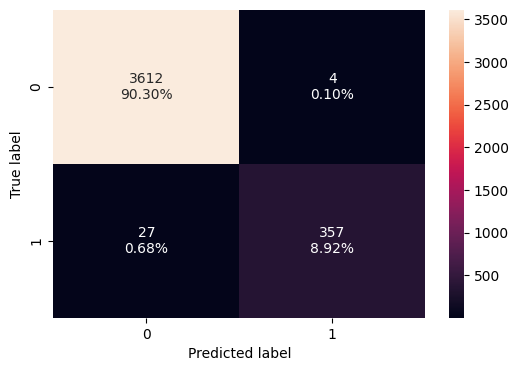

In [94]:
plot_confusion_matrix(transformed_dtree2, transformed_X_train, transformed_y_train)

- True Positives (predicted=1, actual=1): 357 (8.92%)
- True Negatives (predicted=0, actual=0): 3612 (90.30%)
- False Positives (predicted=1, actual=0): 4 (0.10%)
- False Negatives (predicted=0, actual=1): 27 (0.68%)

In [95]:
transformed_dtree2_train_perf = model_performance_classification(
    transformed_dtree2, transformed_X_train, transformed_y_train
)
transformed_dtree2_train_perf

,Accuracy,Recall,Precision,F1
0,0.99225,0.929688,0.98892,0.958389


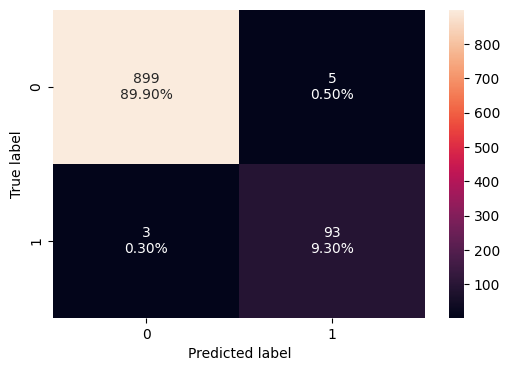

In [96]:
plot_confusion_matrix(transformed_dtree2, transformed_X_test, transformed_y_test)

- True Positives (predicted=1, actual=1): 93 (9.30%)
- True Negatives (predicted=0, actual=0): 899 (89.90%)
- False Positives (predicted=1, actual=0): 5 (0.50%)
- False Negatives (predicted=0, actual=1): 3 (0.30%)

In [97]:
transformed_dtree2_test_perf = model_performance_classification(
    transformed_dtree2, transformed_X_test, transformed_y_test
)
transformed_dtree2_test_perf

,Accuracy,Recall,Precision,F1
0,0.992,0.96875,0.94898,0.958763


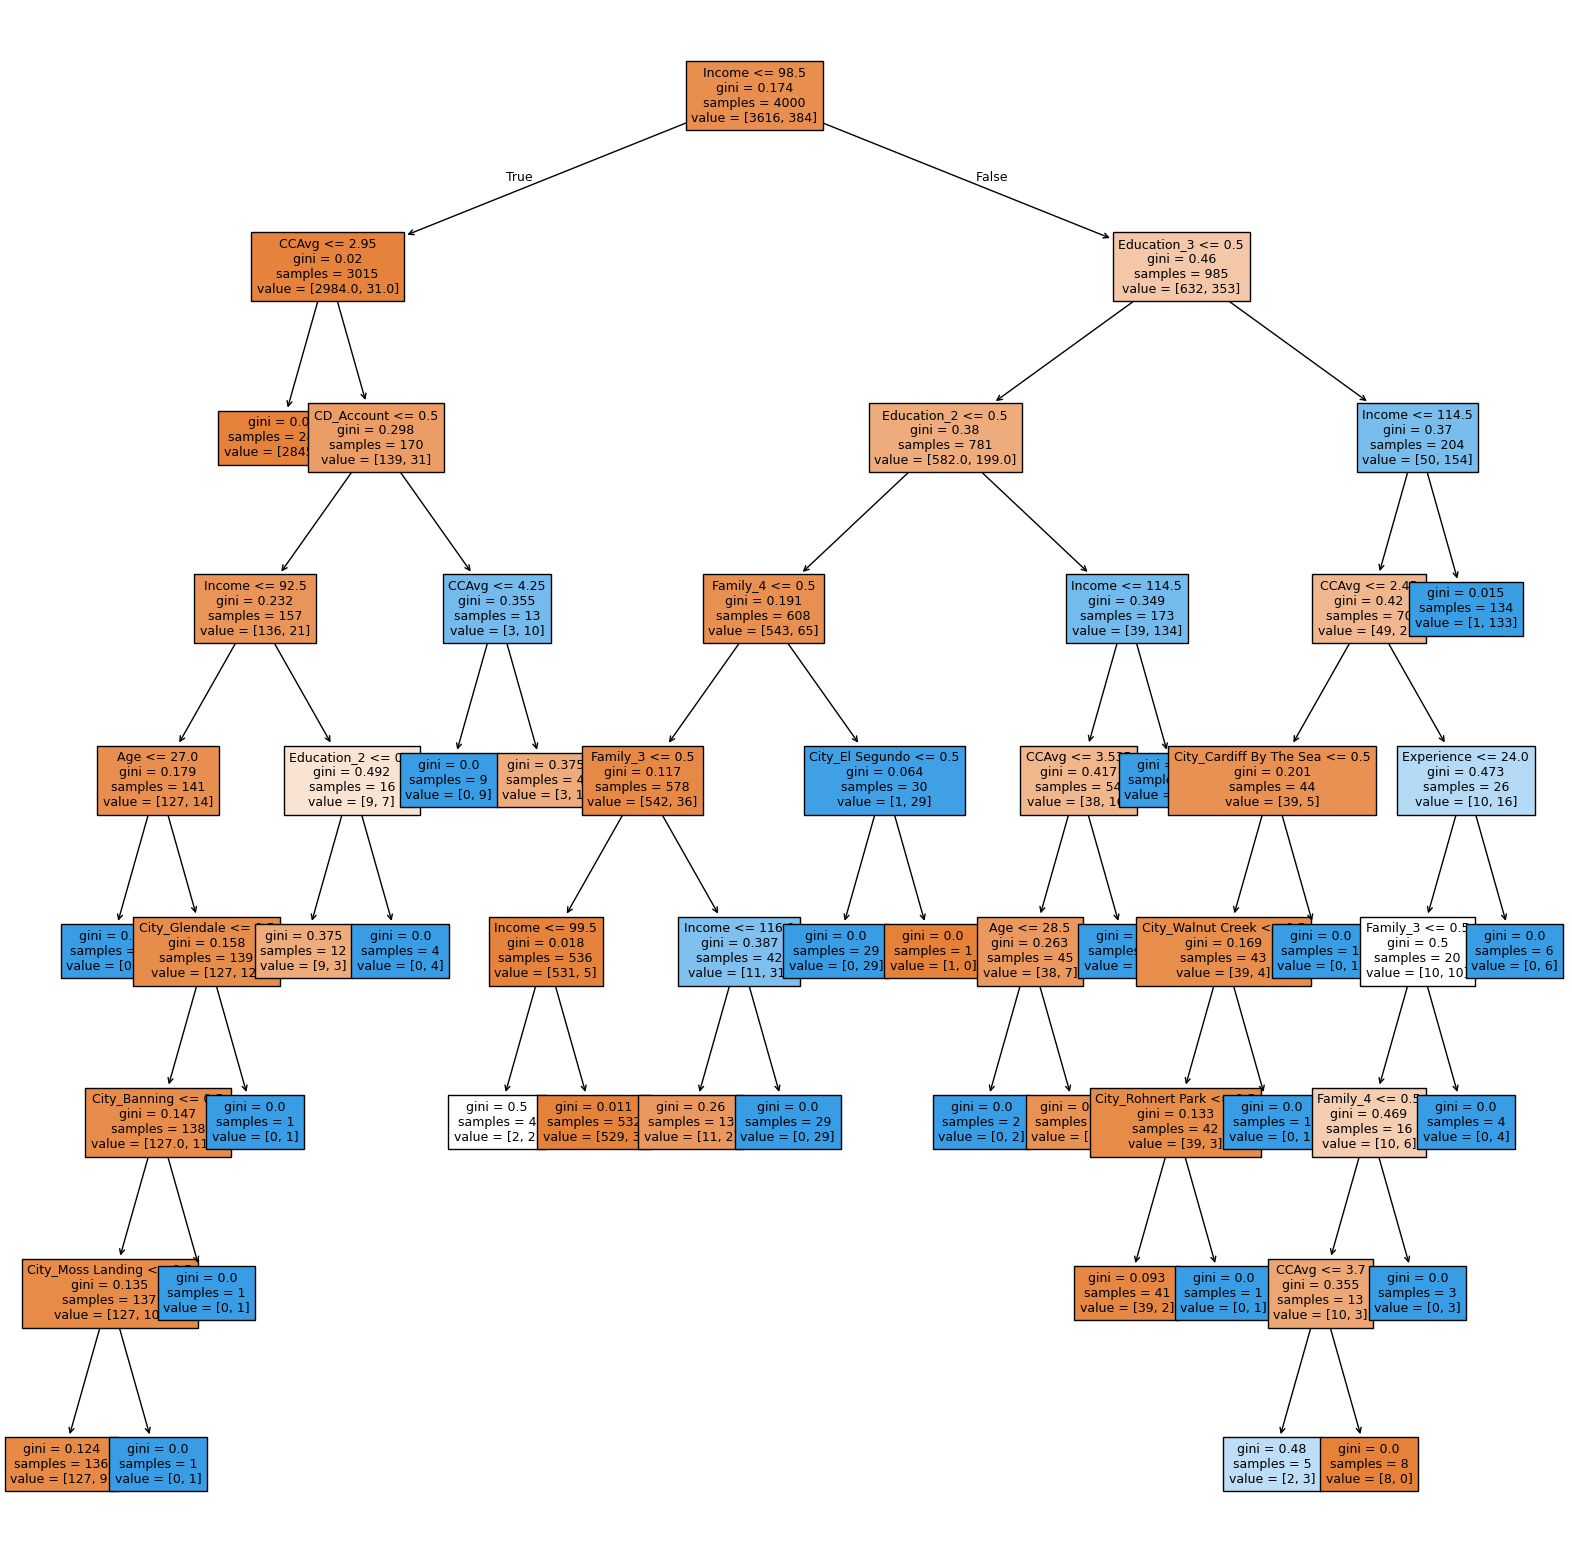

In [98]:
# list of feature names in X_train
feature_names = list(transformed_X_train.columns)
tree_plot(transformed_dtree2, feature_names)

In [99]:
# printing a text report showing the rules of a decision tree
print_rules(transformed_dtree2,feature_names)

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2845.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 92.50
|   |   |   |   |--- Age <= 27.00
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- Age >  27.00
|   |   |   |   |   |--- City_Glendale <= 0.50
|   |   |   |   |   |   |--- City_Banning <= 0.50
|   |   |   |   |   |   |   |--- City_Moss Landing <= 0.50
|   |   |   |   |   |   |   |   |--- weights: [127.00, 9.00] class: 0
|   |   |   |   |   |   |   |--- City_Moss Landing >  0.50
|   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |--- City_Banning >  0.50
|   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |--- City_Glendale >  0.50
|   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |--- Income >  92.50
|   |   |   |   |--- Education_2 <= 0.50
|   |   |   |   |   |--- weights: [9.00, 3.00] cl

The decision tree primarily splits on Income (98.50K) as the root node, followed by CCAvg (2.95K) and Education levels as key decision points. While California cities (like Glendale, Banning, El Segundo) appear in the decision rules, they play a minor role in fine-tuning predictions within already segmented groups, showing that location is less influential than financial and educational factors. The tree maintains similar structure to the original with city names replacing ZIP codes, suggesting geographical location adds minimal predictive value to loan acceptance probability.

### **Decision Tree (Post-pruning)**

In [100]:
# Create an instance of the decision tree model
clf = DecisionTreeClassifier(random_state=42)

# Compute the cost complexity pruning path for the model using the training data
path = clf.cost_complexity_pruning_path(transformed_X_train, transformed_y_train)

# Extract the array of effective alphas from the pruning path
ccp_alphas = abs(path.ccp_alphas)

# Extract the array of total impurities at each alpha along the pruning path
impurities = path.impurities

In [101]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000244,0.001463
2,0.000248,0.001959
3,0.000248,0.002455
4,0.000249,0.003946
5,0.000300,0.004546
6,0.000313,0.005486
7,0.000317,0.006436
8,0.000375,0.007561
9,0.000375,0.007936


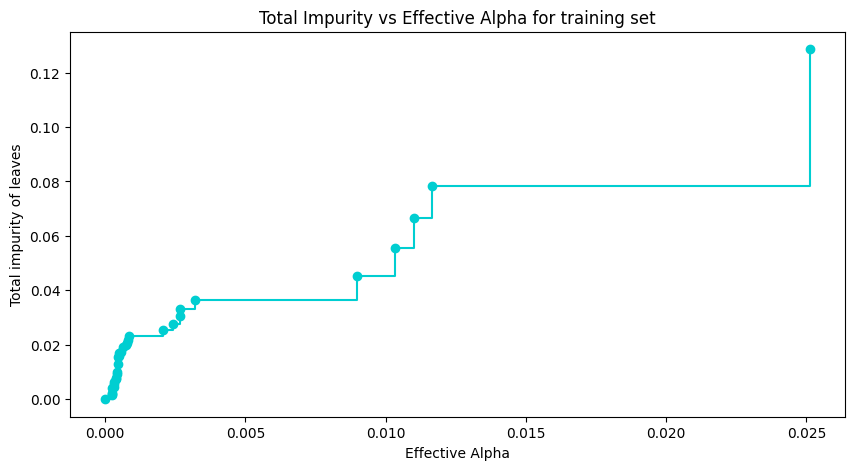

In [102]:
# plotting ccp_alphas vs impurities
ccp_alphas_vs_impurities(ccp_alphas,impurities)

The plot shows a stepwise increase in total impurity as the effective alpha value increases, with several distinct plateaus and sharp jumps occurring around alpha values of 0.001 and 0.01. The most dramatic increase in impurity occurs at alpha = 0.025, jumping from 0.08 to 0.12, indicating significant tree simplification at this point. The pattern suggests that pruning occurs in discrete steps rather than continuously, with the tree maintaining relatively stable complexity between these critical alpha values.

In [103]:
# Initialize an empty list to store the decision tree classifiers
clfs = []

# Iterate over each ccp_alpha value extracted from cost complexity pruning path
for ccp_alpha in ccp_alphas:
    # Create an instance of the DecisionTreeClassifier
    clf = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=42)

    # Fit the classifier to the training data
    clf.fit(transformed_X_train, transformed_y_train)

    # Append the trained classifier to the list
    clfs.append(clf)

# Print the number of nodes in the last tree along with its ccp_alpha value
print(
    "Number of nodes in the last tree is {} with ccp_alpha {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is 1 with ccp_alpha 0.04498066930996447


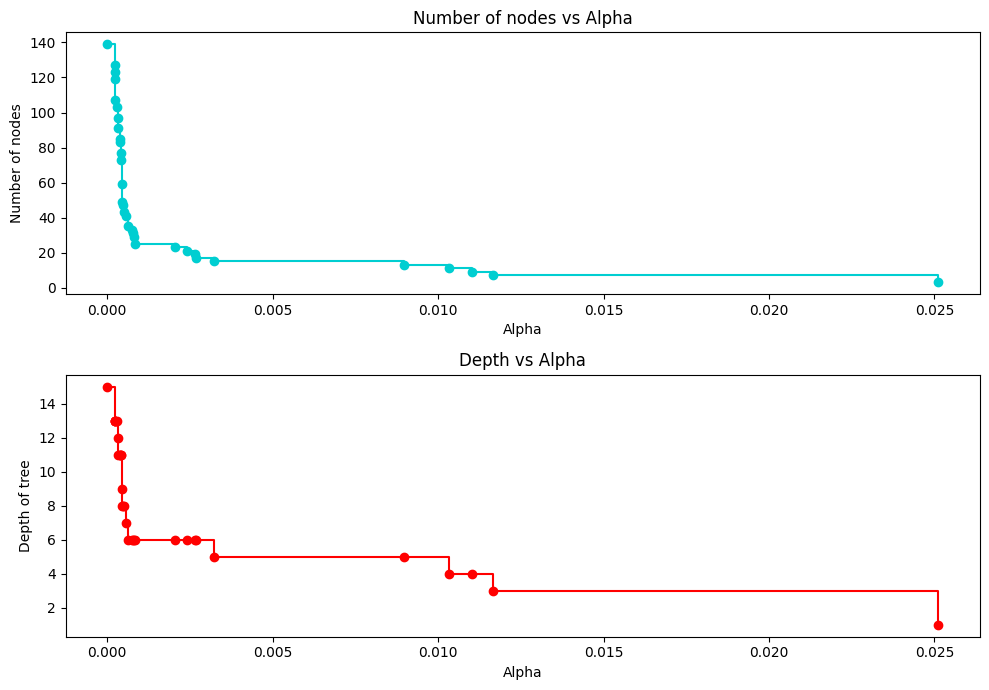

In [104]:
# Plotting ccp_alphas vs number of nodes and depth of tree
ccp_alpha_vs_nodes_and_depth(clfs,ccp_alphas)

The plots shows increasing alpha affects tree complexity through post-pruning. The number of nodes drops sharply from 140 to around 20 nodes at very low alpha values (0.000-0.002), then stabilizes with gradual reduction. Similarly, the tree depth decreases from 15 to 6 levels initially, followed by step-wise reductions to around 3 levels at higher alpha values, indicating effective pruning while maintaining essential decision structure.

In [105]:
train_f1_scores = []  # Initialize an empty list to store F1 scores for training set for each decision tree classifier

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
    # Predict labels for the training set using the current decision tree classifier
    pred_train = clf.predict(transformed_X_train)

    # Calculate the F1 score for the training set predictions compared to true labels
    f1_train = f1_score(transformed_y_train, pred_train)

    # Append the calculated F1 score to the train_f1_scores list
    train_f1_scores.append(f1_train)

In [106]:
test_f1_scores = []  # Initialize an empty list to store F1 scores for test set for each decision tree classifier

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
    # Predict labels for the test set using the current decision tree classifier
    pred_test = clf.predict(transformed_X_test)

    # Calculate the F1 score for the test set predictions compared to true labels
    f1_test = f1_score(transformed_y_test, pred_test)

    # Append the calculated F1 score to the test_f1_scores list
    test_f1_scores.append(f1_test)


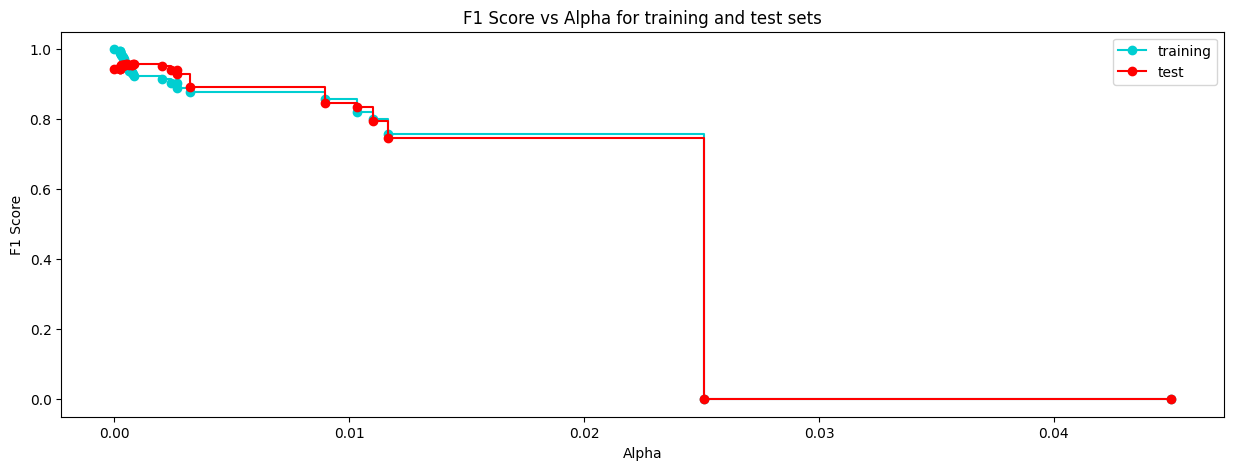

In [107]:
# Plotting F1 Score vs Alpha for training and test sets
ccp_alphas_vs_f1_scores(ccp_alphas,train_f1_scores,test_f1_scores)

The plot shows F1 scores for both training and test sets as the alpha parameter increases, with both sets maintaining high F1 scores (around 0.95) and similar performance up to alpha ≈ 0.01. There's a noticeable drop in F1 scores for both sets around alpha 0.01-0.015, after which they stabilize at around 0.75, before the train and test set dramatically drops to 0 at alpha = 0.025, indicating over-pruning at this point.

In [108]:
# creating the model where we get highest test F1 Score
index_best_model = np.argmax(test_f1_scores)

# selcting the decision tree model corresponding to the highest test score
transformed_dtree3 = clfs[index_best_model]
print(transformed_dtree3)

DecisionTreeClassifier(ccp_alpha=0.0004925688755470787, random_state=42)


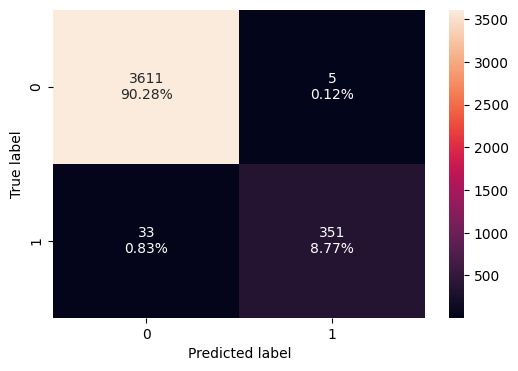

In [109]:
plot_confusion_matrix(transformed_dtree3, transformed_X_train, transformed_y_train)

- True Positives (predicted=1, actual=1): 351 (8.77%)
- True Negatives (predicted=0, actual=0): 3611 (90.28%)
- False Positives (predicted=1, actual=0): 5 (0.12%)
- False Negatives (predicted=0, actual=1): 33 (0.83%)

In [110]:
transformed_dtree3_train_perf = model_performance_classification(
    transformed_dtree3, transformed_X_train, transformed_y_train
)
transformed_dtree3_train_perf

,Accuracy,Recall,Precision,F1
0,0.9905,0.914062,0.985955,0.948649


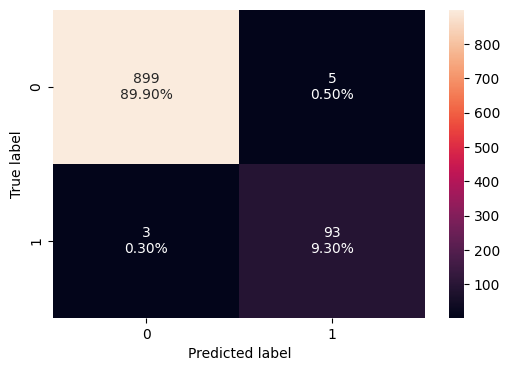

In [111]:
plot_confusion_matrix(transformed_dtree3, transformed_X_test, transformed_y_test)

- True Positives (predicted=1, actual=1): 93 (9.30%)
- True Negatives (predicted=0, actual=0): 899 (89.90%)
- False Positives (predicted=1, actual=0): 5 (0.50%)
- False Negatives (predicted=0, actual=1): 3 (0.30%)

In [112]:
transformed_dtree3_test_perf = model_performance_classification(
    transformed_dtree3, transformed_X_test, transformed_y_test
)
transformed_dtree3_test_perf

,Accuracy,Recall,Precision,F1
0,0.992,0.96875,0.94898,0.958763


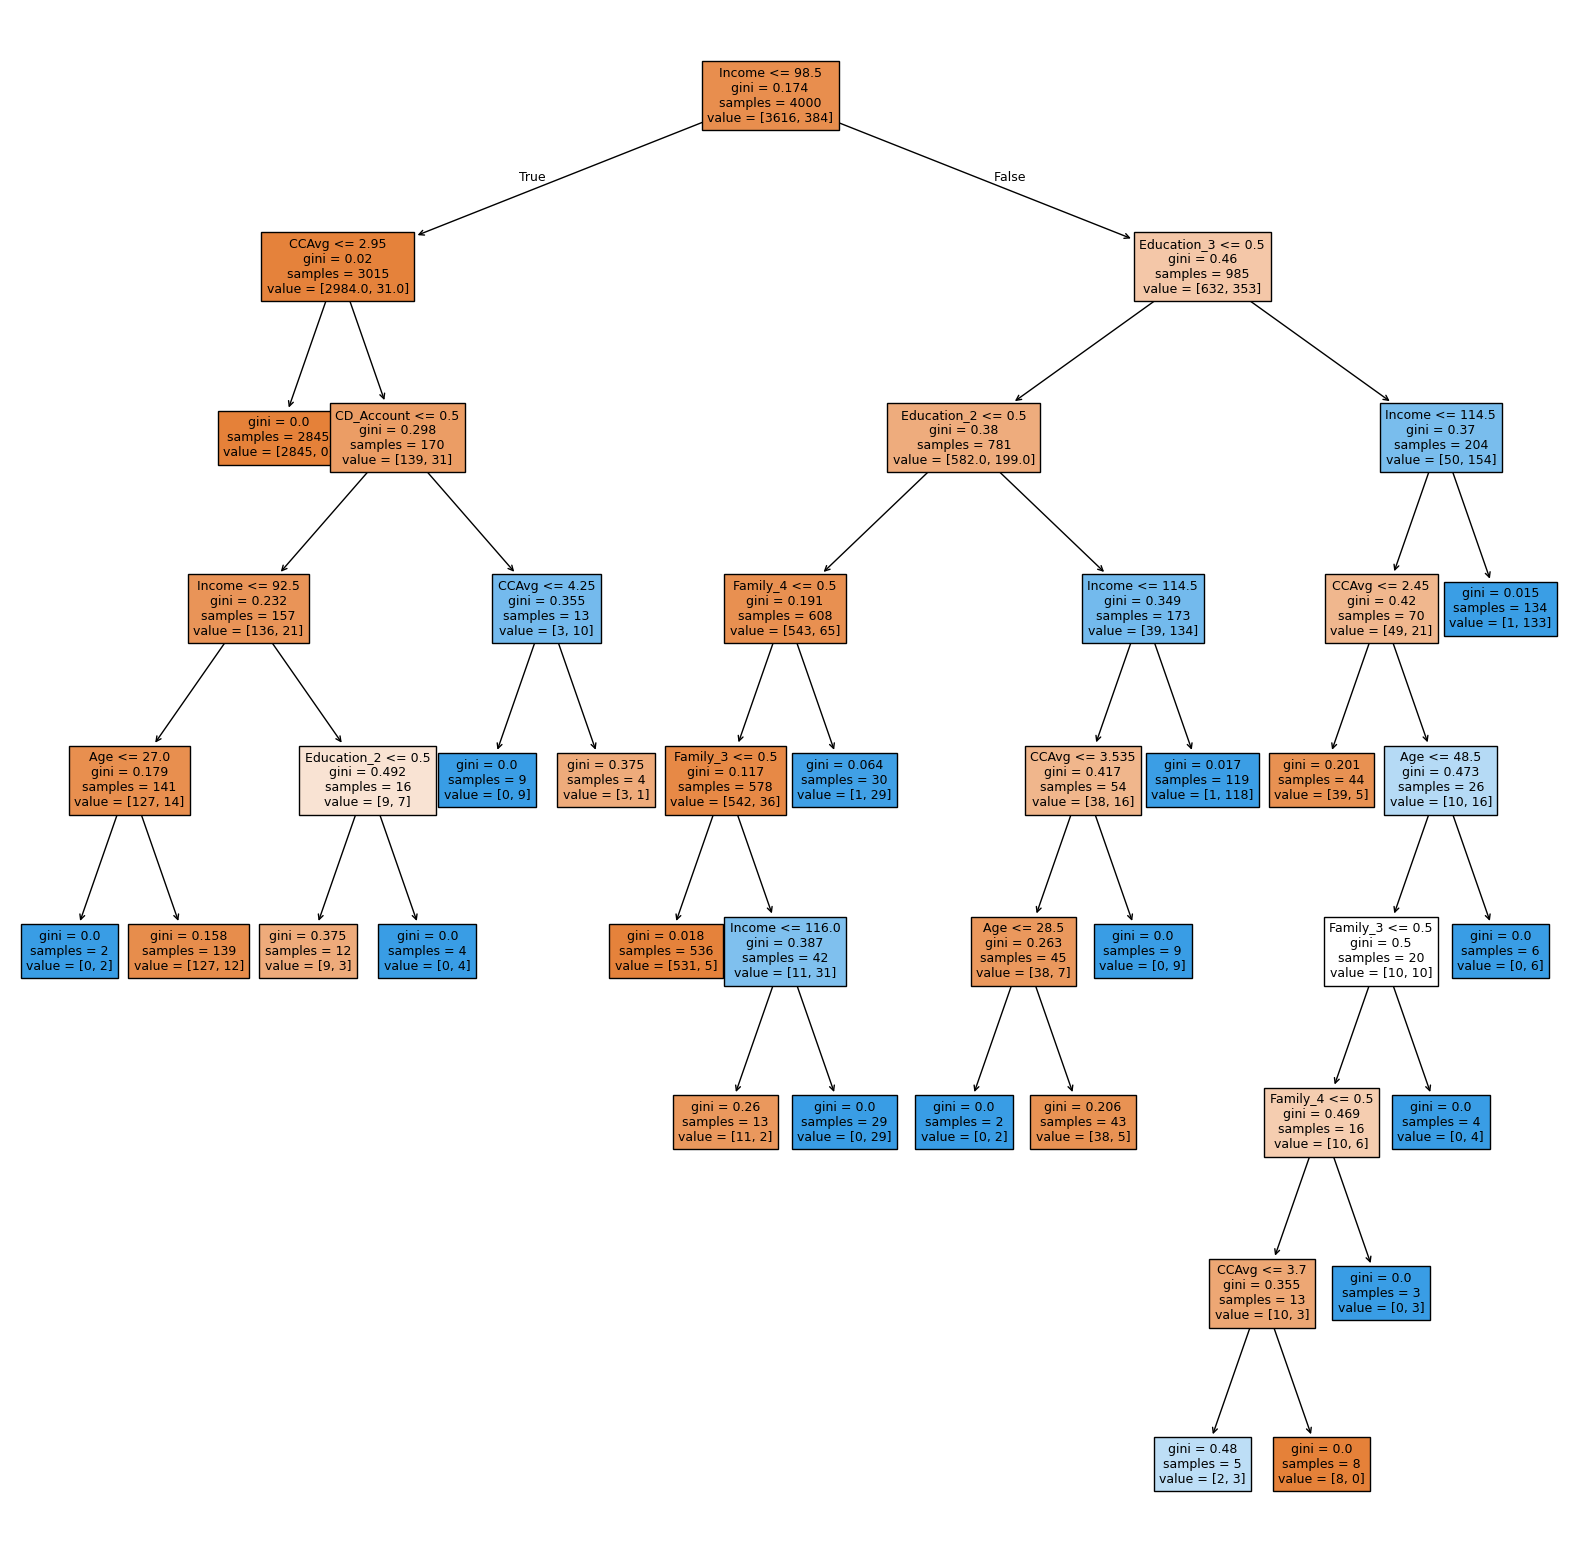

In [113]:
# list of feature names in X_train
feature_names = list(transformed_X_train.columns)
tree_plot(transformed_dtree3, feature_names)

In [114]:
# printing a text report showing the rules of a decision tree
print_rules(transformed_dtree3,feature_names)

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2845.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 92.50
|   |   |   |   |--- Age <= 27.00
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- Age >  27.00
|   |   |   |   |   |--- weights: [127.00, 12.00] class: 0
|   |   |   |--- Income >  92.50
|   |   |   |   |--- Education_2 <= 0.50
|   |   |   |   |   |--- weights: [9.00, 3.00] class: 0
|   |   |   |   |--- Education_2 >  0.50
|   |   |   |   |   |--- weights: [0.00, 4.00] class: 1
|   |   |--- CD_Account >  0.50
|   |   |   |--- CCAvg <= 4.25
|   |   |   |   |--- weights: [0.00, 9.00] class: 1
|   |   |   |--- CCAvg >  4.25
|   |   |   |   |--- weights: [3.00, 1.00] class: 0
|--- Income >  98.50
|   |--- Education_3 <= 0.50
|   |   |--- Education_2 <= 0.50
|   |   |   |--- Family_4 <= 0.50
|   |   |   |   |--- Family_3 <= 0.50
|   |   |   |   |   |--- weights: [531.00, 5.00] class: 0


This post-pruned decision tree maintains the same primary structure as the non-transformed version, with key splits on Income (98.50K), CCAvg (2.95K), and Education levels. The main difference is the removal of city-based splits that were present in the pre-pruned version, suggesting that geographical information was less crucial for predictions, resulting in a simpler yet equally effective model focused on financial and educational factors.

----
## **Model Performance Comparison and Final Model Selection**
----

In [115]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        dtree1_train_perf.T,
        transformed_dtree1_train_perf.T,
        dtree2_train_perf.T,
        transformed_dtree2_train_perf.T,
        dtree3_train_perf.T,
        transformed_dtree3_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Transformed Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Transformed Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
    "Transformed Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Transformed Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Transformed Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning),Transformed Decision Tree (Post-Pruning)
Accuracy,1.0,1.0,0.991250,0.992250,0.990500,0.990500
Recall,1.0,1.0,0.927083,0.929688,0.914062,0.914062
Precision,1.0,1.0,0.980716,0.988920,0.985955,0.985955
F1,1.0,1.0,0.953146,0.958389,0.948649,0.948649


In [116]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        dtree1_test_perf.T,
        transformed_dtree1_test_perf.T,
        dtree2_test_perf.T,
        transformed_dtree2_test_perf.T,
        dtree3_test_perf.T,
        transformed_dtree3_test_perf.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Transformed Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Transformed Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
    "Transformed Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Transformed Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Transformed Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning),Transformed Decision Tree (Post-Pruning)
Accuracy,0.981000,0.989000,0.991000,0.992000,0.992000,0.992000
Recall,0.958333,0.968750,0.958333,0.968750,0.968750,0.968750
Precision,0.859813,0.920792,0.948454,0.948980,0.948980,0.948980
F1,0.906404,0.944162,0.953368,0.958763,0.958763,0.958763


The transformed pre-pruned decision tree shows superior performance with higher metrics across the board (Accuracy: 0.992, Recall: 0.969, Precision: 0.949, F1: 0.959) compared to the non-transformed pre-pruned model, suggesting that converting ZIP codes to city names improved the model's predictive capability. While both transformed and non-transformed post-pruned models show identical performance metrics (Accuracy: 0.992, F1: 0.959), we'll proceed with the transformed pre-pruned model as it retains important geographical splits (city-based) and other feature relationships that could be crucial for edge cases, providing more comprehensive decision paths for loan acceptance prediction.

### **Feature Importance**

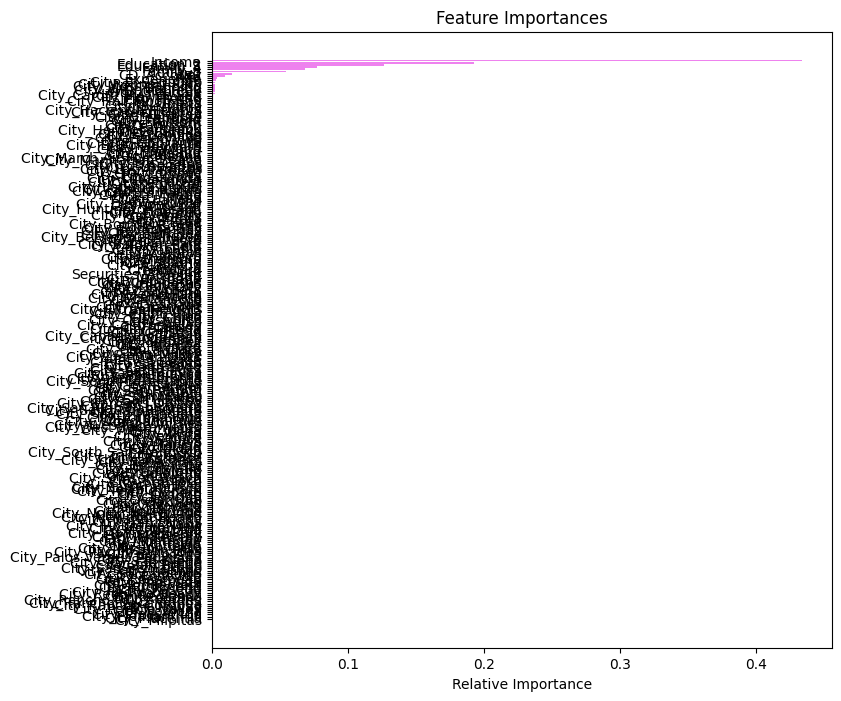

In [117]:
# importance of features in the tree building
importances = transformed_dtree2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

#### **Top 15 Features**

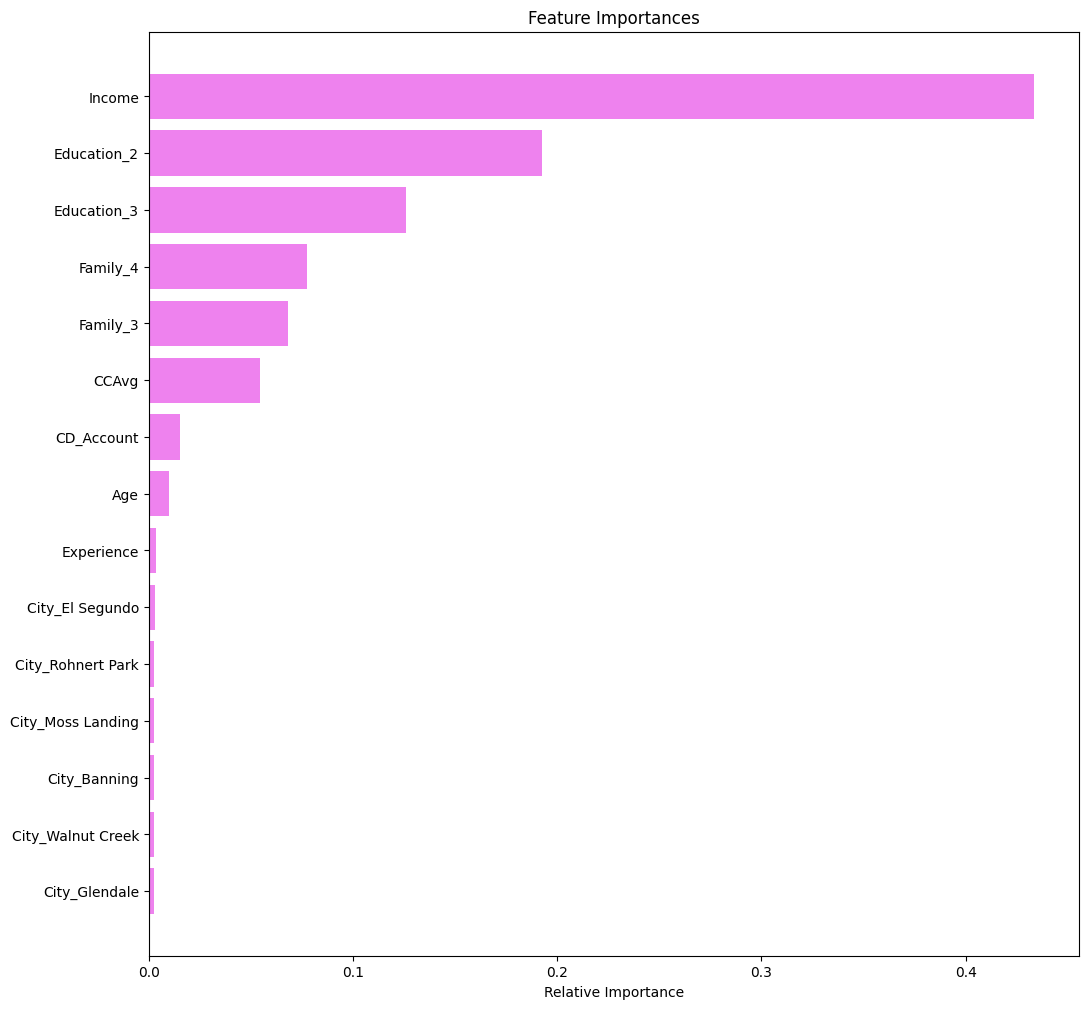

In [118]:
importances = transformed_dtree2.feature_importances_
indices = np.argsort(importances)
selected_indices = indices[-15:]

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(selected_indices)), importances[selected_indices], color="violet", align="center")
plt.yticks(range(len(selected_indices)), [feature_names[i] for i in selected_indices])
plt.xlabel("Relative Importance")
plt.show()

## **Conclusions**

Based on the feature importance visualization and our objective:

#### **Key Predictive Features**
- Income dominates prediction power (~0.42 importance), indicating customers' financial capacity is the primary driver for personal loan acceptance
- Education levels (Education_2 and Education_3 combined ~0.30) strongly influence loan decisions, suggesting higher educated customers are more likely to accept personal loans
- Family size (Family_3 and Family_4 combined ~0.15) and Credit Card spending (~0.08) provide moderate predictive power

#### **Target Customer Segments**
- Primary Target: High-income customers (>98.5K) with graduate/advanced degrees
- Secondary Target: Families with 3-4 members showing higher credit card usage
- Tertiary Target: CD Account holders with consistent credit card spending

#### **Marketing Focus**
- Concentrate on customers' income levels and educational background
- Develop family-specific loan products for larger households
- Leverage credit card spending patterns for targeted marketing
- Geographic location (city-based features) provides minimal predictive value, suggesting location-agnostic marketing strategies.

This analysis helps identify the most promising customer segments for personal loan marketing while optimizing resource allocation based on feature importance.